## Importing dependencies

In [1]:
import pandas as pd
import glob
from obspy.clients.fdsn import Client
import obspy
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import seisbench.models as sbm

from obspy import UTCDateTime

import numpy as np
import ast

## The goal of this notebook 

- gather daily detections at all the stations
- find the events that were commonly detected at atleast four stations
- plot waveforms and probability curves of such events

In [2]:
common_events = pd.read_csv('../logs/common_2025-12-01T00:00:00_to_2025-12-17T14:20:00_events.csv')
common_events

,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
0,2025-12-01 00:00:50+00:00,5,"['LTY', 'MANO', 'RCM', 'JCW', 'RCS']","['su', 'px', 'eq', 'su', 'eq']",eq,14.295711,0.768417,0.452266
1,2025-12-01 00:32:00+00:00,4,"['RER', 'COPP', 'PANH', 'PARA']","['su', 'su', 'su', 'px']",su,4.850496,0.732971,0.430646
2,2025-12-01 00:43:50+00:00,4,"['KAVK', 'MILD', 'OBSR', 'RCS']","['eq', 'px', 'su', 'eq']",eq,5.666386,0.652843,0.345965
3,2025-12-01 01:24:00+00:00,5,"['RER', 'COPP', 'PARA', 'RCS', 'STAR']","['su', 'su', 'su', 'eq', 'su']",su,3.576699,0.604469,0.376319
4,2025-12-01 01:26:20+00:00,5,"['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']","['su', 'su', 'su', 'su', 'su']",su,21.986420,0.931628,0.607378
...,...,...,...,...,...,...,...,...
760,2025-12-17 04:35:50+00:00,5,"['BHW', 'GPW', 'LTY', 'RER', 'OBSR']","['su', 'su', 'su', 'eq', 'su']",su,7.259340,0.652305,0.355709
761,2025-12-17 04:52:00+00:00,5,"['PASS', 'RER', 'WRW', 'KAVK', 'VOIT']","['eq', 'px', 'eq', 'eq', 'px']",eq,6.000057,0.763182,0.455848
762,2025-12-17 06:20:20+00:00,4,"['CRYS', 'GPW', 'MILD', 'RUSH']","['px', 'su', 'su', 'px']",px,4.964412,0.641954,0.380471
763,2025-12-17 07:55:30+00:00,4,"['GRWR', 'MULN', 'SHUK', 'GSM']","['eq', 'su', 'su', 'su']",su,5.884277,0.617498,0.393216


In [3]:
## Counting the number of detections for each class
common_events['most_common_class'].value_counts()

most_common_class
su    376
eq    237
px    152
Name: count, dtype: int64

In [4]:
## Finding detections that had same class over all stations. 
def is_uniform(lst):
    return len(set(lst)) == 1

df = common_events.copy()
df['all_classes'] = df['all_classes'].apply(ast.literal_eval)


uniform_df = df[df['all_classes'].apply(is_uniform)]
uniform_df

,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
4,2025-12-01 01:26:20+00:00,5,"['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']","[su, su, su, su, su]",su,21.986420,0.931628,0.607378
6,2025-12-01 01:26:50+00:00,5,"['SUNT', 'FMW', 'HTW', 'RPW2', 'RCS']","[su, su, su, su, su]",su,12.253034,0.847616,0.524463
7,2025-12-01 01:27:00+00:00,4,"['LOKMT', 'LON', 'COPP', 'PARA']","[su, su, su, su]",su,11.092132,0.827567,0.499348
15,2025-12-01 01:31:50+00:00,4,"['DREAM', 'HTW', 'CARB', 'CRBN']","[su, su, su, su]",su,3.366616,0.595179,0.381963
16,2025-12-01 01:38:20+00:00,4,"['RER', 'COPP', 'PANH', 'PARA']","[su, su, su, su]",su,4.657438,0.774589,0.457177
...,...,...,...,...,...,...,...,...
750,2025-12-16 19:54:50+00:00,4,"['GPW', 'SHUK', 'TOLT', 'WRW']","[eq, eq, eq, eq]",eq,3.623255,0.727162,0.417541
753,2025-12-16 23:39:30+00:00,6,"['LOKMT', 'PASS', 'COPP', 'PALI', 'RUSH', 'SIFT']","[px, px, px, px, px, px]",px,3.302078,0.603461,0.365670
754,2025-12-16 23:39:40+00:00,4,"['SUNT', 'LTY', 'TBLMT', 'LONR']","[px, px, px, px]",px,2.745279,0.569903,0.363640
756,2025-12-17 00:59:00+00:00,4,"['RCM', 'SHUK', 'MILD', 'OBSR']","[su, su, su, su]",su,6.698956,0.707501,0.397538


In [5]:
uniform_df['most_common_class'].value_counts()

most_common_class
su    180
eq     89
px     34
Name: count, dtype: int64

## We want to plot these events, their waveforms and probability curves

In [6]:
# Load model
model = sbm.QuakeXNet.from_pretrained("base", version_str = '3')



In [7]:
def plot_event_waveforms(event_row, duration=300, peak_thresh=0.50):
    client      = Client("IRIS")
    event_time  = UTCDateTime(pd.to_datetime(event_row["rounded_start"]).to_pydatetime())
    stations    = ast.literal_eval(event_row["stations"])
    target_cls  = event_row["most_common_class"]

    fig, ax = plt.subplots(figsize=(10, 2 * len(stations)))

    y_offsets = []
    for i, sta in enumerate(np.unique(stations)):
        try:
            
            st = client.get_waveforms("*", sta, "*", "*HZ",
                                      starttime=event_time - 100,
                                      endtime=event_time + duration)
            st.resample(50)

            # ── inference ───────────────────────────────────────────────
            probs_st = model.annotate(st, stride=500)
            probs_tr = probs_st.select(channel=f"QuakeXNet_{target_cls}")[0]
            t_probs  = probs_tr.times() + 50
            d_probs  = probs_tr.data

            # ── waveform prep ───────────────────────────────────────────
            st.detrend("linear"); st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)
  
            tr       = st[0]
            t_wave   = tr.times("relative")
            y_wave   = tr.data / np.abs(tr.data).max()

            # ── plot ────────────────────────────────────────────────────
            offset = 2 * i
            y_offsets.append(offset)
            ax.plot(t_wave,  y_wave + offset,  lw=0.6, color="black")
            ax.plot(t_probs, d_probs + offset, lw=1.2, color = 'red', label = target_cls)

            # annotate peaks above threshold
            peaks = np.where((d_probs[1:-1] > d_probs[:-2]) &
                             (d_probs[1:-1] > d_probs[2:]) &
                             (d_probs[1:-1] >= peak_thresh))[0] + 1
            for p in peaks:
                ax.text(t_probs[p], d_probs[p] + offset + 0.05,
                        f"{d_probs[p]:.2f}", ha="center", va="bottom",
                        fontsize=7, color="darkblue")
        except Exception as e:
            print(f"❌ {sta}: {e}")

    # ── styling ────────────────────────────────────────────────────────
    ax.axvline(100, color="red", ls="--")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}")
    ax.legend()

    try:
    # put station names on y-axis at the row centers
        ax.set_yticks(y_offsets)
        ax.set_yticklabels(np.unique(stations))
        ax.set_ylabel("Station")
    except:
        pass

    #ax.set_xlim(0, 60)
    ax.set_ylim(-1, 2 * len(np.unique(stations)))
    plt.tight_layout()
    plt.savefig(f"figures/Event_{target_cls.upper()}_{event_time.isoformat()}.png")
    plt.show()


In [11]:
def plot_event_waveforms_general(event_row, duration=300, peak_thresh=0.50):
    import ast
    import numpy as np
    from collections import defaultdict
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    from obspy.clients.fdsn import Client
    from obspy import UTCDateTime

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------
    client = Client("IRIS")
    event_time = UTCDateTime(pd.to_datetime(event_row["rounded_start"]).to_pydatetime())

    stations = ast.literal_eval(event_row["stations"])

    try:
        all_classes = ast.literal_eval(event_row["all_classes"])
    except Exception:
        all_classes = event_row["all_classes"]

    target_cls = event_row["most_common_class"]

    # ------------------------------------------------------------------
    # Build station → detected classes mapping
    # ------------------------------------------------------------------
    station_classes = defaultdict(set)
    for sta, cls in zip(stations, all_classes):
        station_classes[sta].add(cls)

    unique_stations = list(station_classes.keys())

    # ------------------------------------------------------------------
    # Fetch station coordinates from IRIS
    # ------------------------------------------------------------------
    station_coords = {}
    for sta in unique_stations:
        try:
            inv = client.get_stations(station=sta, level="station")
            for net in inv:
                for s in net:
                    station_coords[sta] = (s.latitude, s.longitude)
        except Exception as e:
            print(f"⚠️ Could not fetch coords for {sta}: {e}")

    # ------------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(13, 2 * len(unique_stations)))
    gs = gridspec.GridSpec(
        nrows=1,
        ncols=2,
        width_ratios=[4.5, 1.5],
        wspace=0.25
    )

    ax = fig.add_subplot(gs[0])
    y_offsets = []

    # ------------------------------------------------------------------
    # Waveform + model inference plots
    # ------------------------------------------------------------------
    for i, sta in enumerate(unique_stations):
        try:
            st = client.get_waveforms(
                "*", sta, "*", "*HN,*HE,*HZ",
                starttime=event_time - 100,
                endtime=event_time + duration
            )

            st.resample(50)

            model = sbm.QuakeXNet.from_pretrained("base", version_str="3")
            probs_st = model.annotate(st, stride=500)

            probs_su = probs_st.select(channel="QuakeXNet_su")[0]
            probs_eq = probs_st.select(channel="QuakeXNet_eq")[0]
            probs_px = probs_st.select(channel="QuakeXNet_px")[0]

            t_probs = probs_su.times() + 50
            d_probs_su = probs_su.data
            d_probs_eq = probs_eq.data
            d_probs_px = probs_px.data

            st.detrend("linear")
            st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)

            tr = st[0]
            t_wave = tr.times("relative")
            y_wave = tr.data / np.abs(tr.data).max()

            offset = 2 * i
            y_offsets.append(offset)

            ax.plot(t_wave, y_wave + offset, lw=0.6, color="black")
            ax.plot(t_probs, d_probs_su + offset, lw=1.2, color="red",
                    label="Su" if i == 0 else "")
            ax.plot(t_probs, d_probs_eq + offset, lw=1.2, color="blue",
                    label="Eq" if i == 0 else "")
            ax.plot(t_probs, d_probs_px + offset, lw=1.2, color="green",
                    label="Px" if i == 0 else "")

            # Annotate SU peaks
            peaks = np.where(
                (d_probs_su[1:-1] > d_probs_su[:-2]) &
                (d_probs_su[1:-1] > d_probs_su[2:]) &
                (d_probs_su[1:-1] >= peak_thresh)
            )[0] + 1

            for p in peaks:
                ax.text(
                    t_probs[p],
                    d_probs_su[p] + offset + 0.05,
                    f"{d_probs_su[p]:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    color="darkred"
                )

        except Exception as e:
            print(f"❌ {sta}: {e}")

    # ------------------------------------------------------------------
    # Waveform plot styling
    # ------------------------------------------------------------------
    ax.axvline(100, color="red", ls="--")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Station (detected classes)")
    ax.set_title(f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}")
    ax.legend()

    ax.set_yticks(y_offsets)
    ax.set_yticklabels([
        f"{sta} ({','.join(sorted(station_classes[sta]))})"
        for sta in unique_stations
    ])

    ax.set_ylim(-1, 2 * len(unique_stations))

    # ------------------------------------------------------------------
    # Rich station location map
    # ------------------------------------------------------------------
    map_ax = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

    map_ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    map_ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)

    map_ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8)
    map_ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6)
    map_ax.add_feature(
        cfeature.STATES.with_scale("50m"),
        linewidth=0.4,
        edgecolor="gray"
    )
    map_ax.add_feature(
        cfeature.LAKES.with_scale("50m"),
        facecolor="none",
        edgecolor="blue",
        linewidth=0.4
    )
    map_ax.add_feature(
        cfeature.RIVERS.with_scale("50m"),
        edgecolor="blue",
        linewidth=0.3
    )

    if station_coords:
        lats, lons = zip(*station_coords.values())
        pad = 5.0  # zoomed-out view
        map_ax.set_extent([
            min(lons) - pad, max(lons) + pad,
            min(lats) - pad, max(lats) + pad
        ])

        map_ax.scatter(
            lons, lats,
            s=40,
            color="darkred",
            edgecolor="black",
            transform=ccrs.PlateCarree(),
            zorder=3
        )

    # Major city labels (adjust as needed)
    cities = {
        "Seattle": (47.6062, -122.3321),
        "Portland": (45.5152, -122.6784),
        "San Francisco": (37.7749, -122.4194),
        "Los Angeles": (34.0522, -118.2437),
        "Vancouver": (49.2827, -123.1207)
    }

    for name, (lat, lon) in cities.items():
        map_ax.text(
            lon, lat,
            name,
            fontsize=6,
            transform=ccrs.PlateCarree(),
            ha="left",
            va="bottom",
            zorder=4
        )

    map_ax.set_title("Station Locations", fontsize=9)

    # ------------------------------------------------------------------
    # Finalize
    # ------------------------------------------------------------------
    plt.tight_layout()
    #plt.savefig(f"figures/Event_{target_cls.upper()}_{event_time.isoformat()}.png")
    plt.show()


In [58]:
su_events = uniform_df[uniform_df['most_common_class'] == 'su']

In [59]:
su_events.to_csv('../logs/surface_event_detections_1_17_december_2025.csv')

<Axes: >

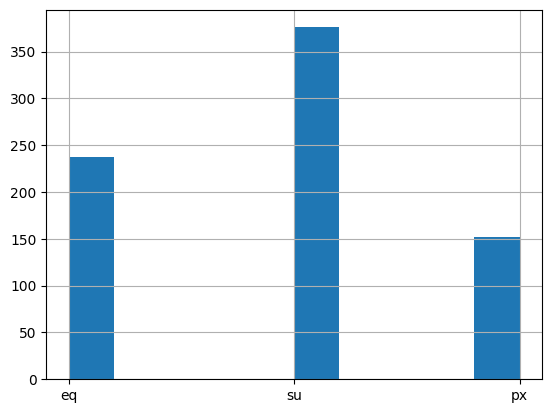

In [12]:
common_events['most_common_class'].hist()

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


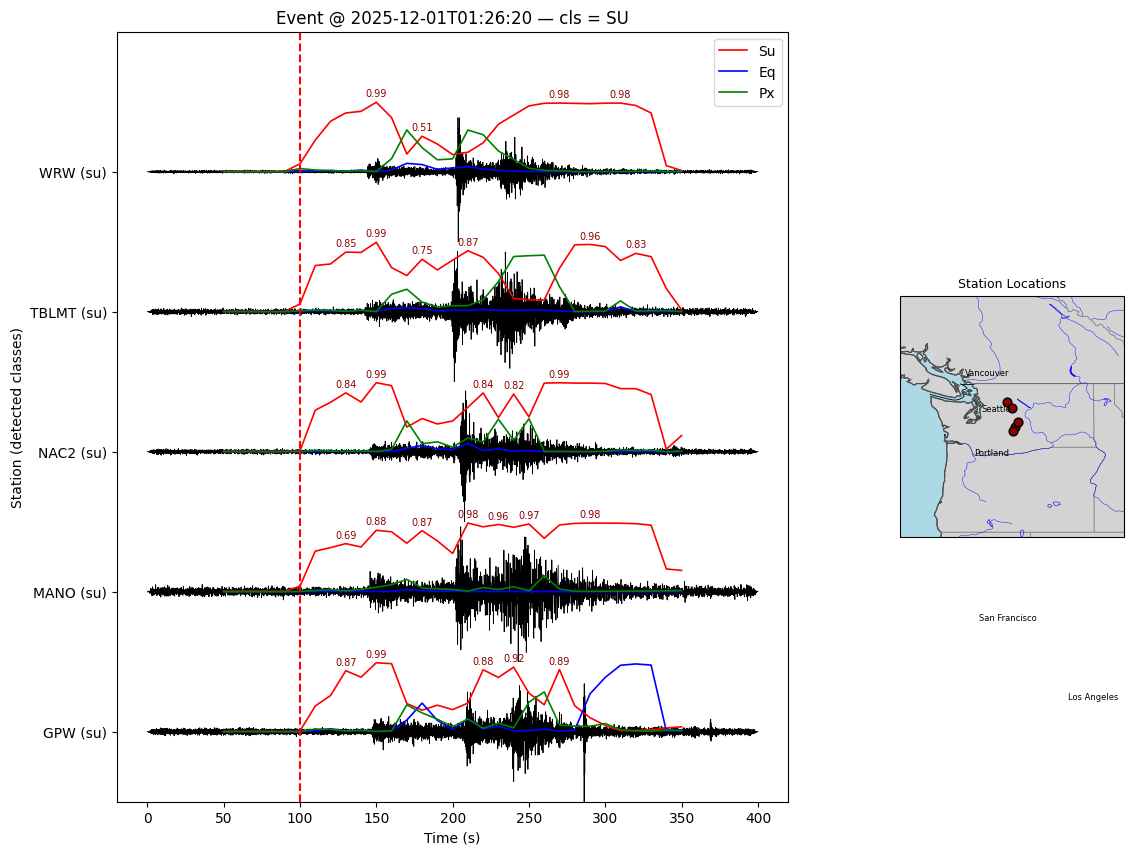

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


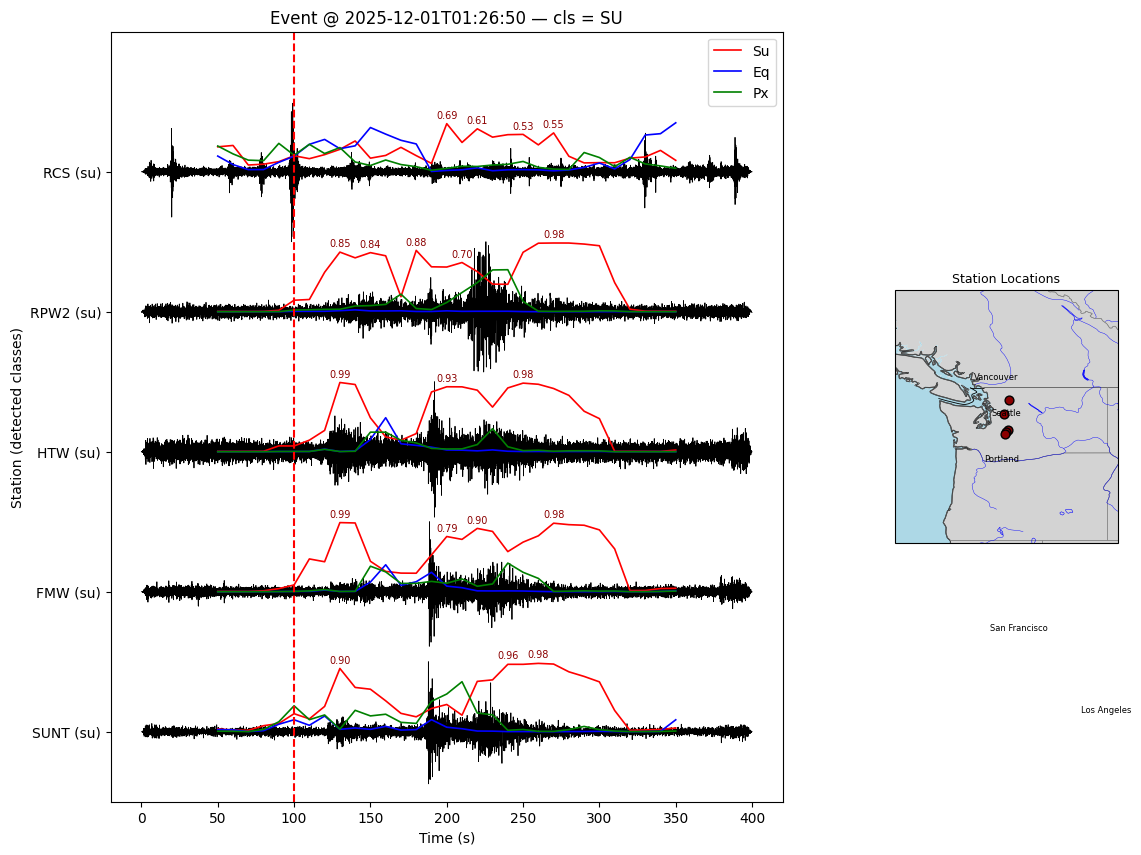

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


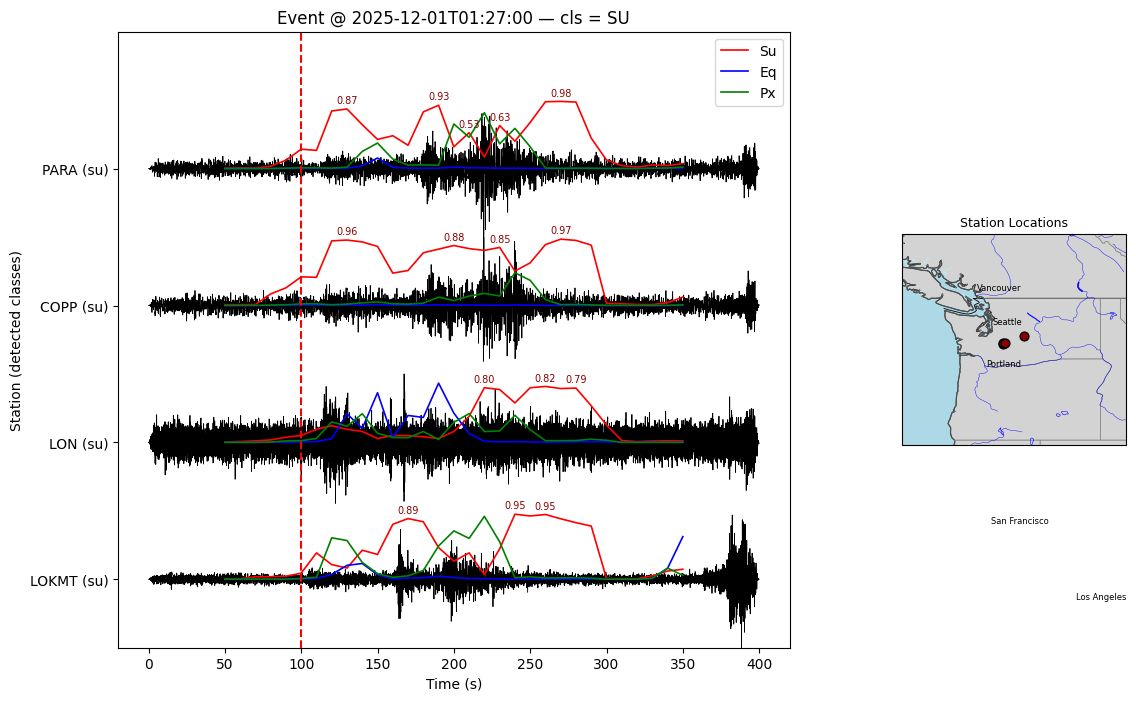

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


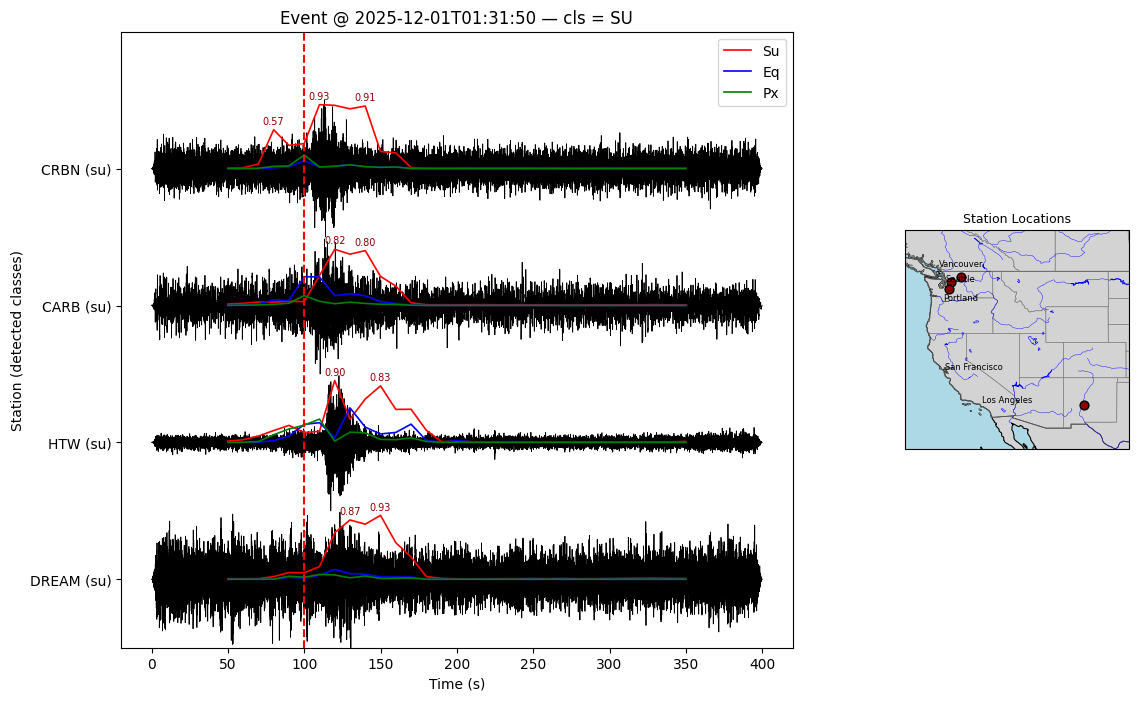

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


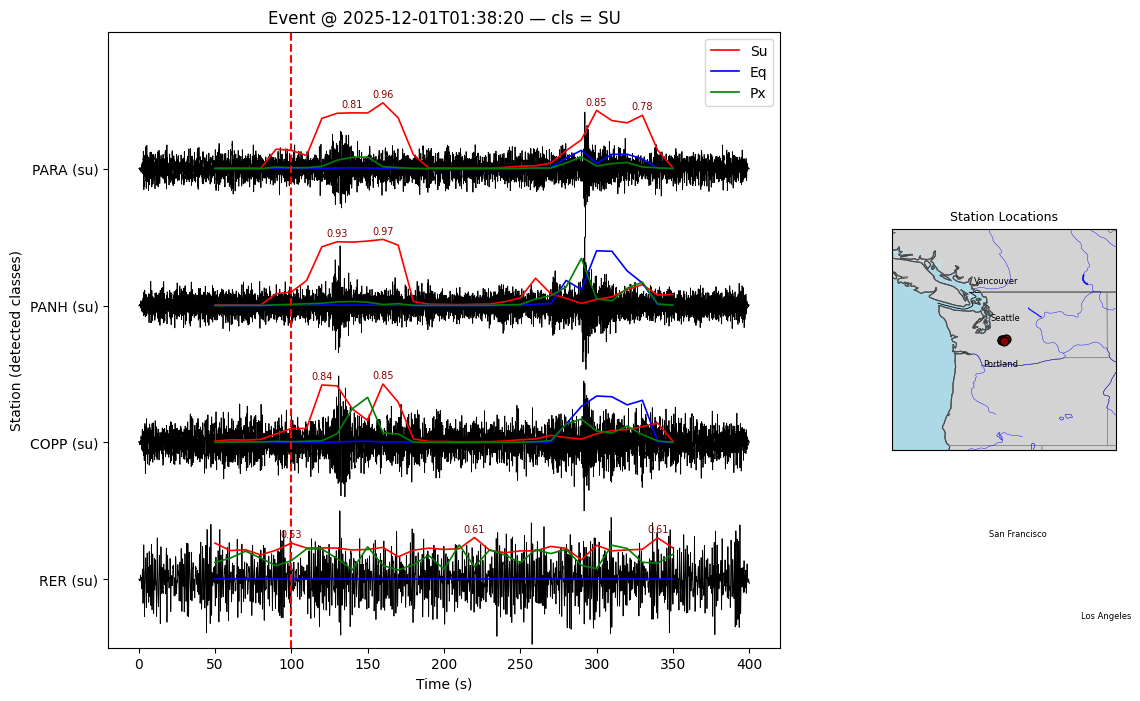

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


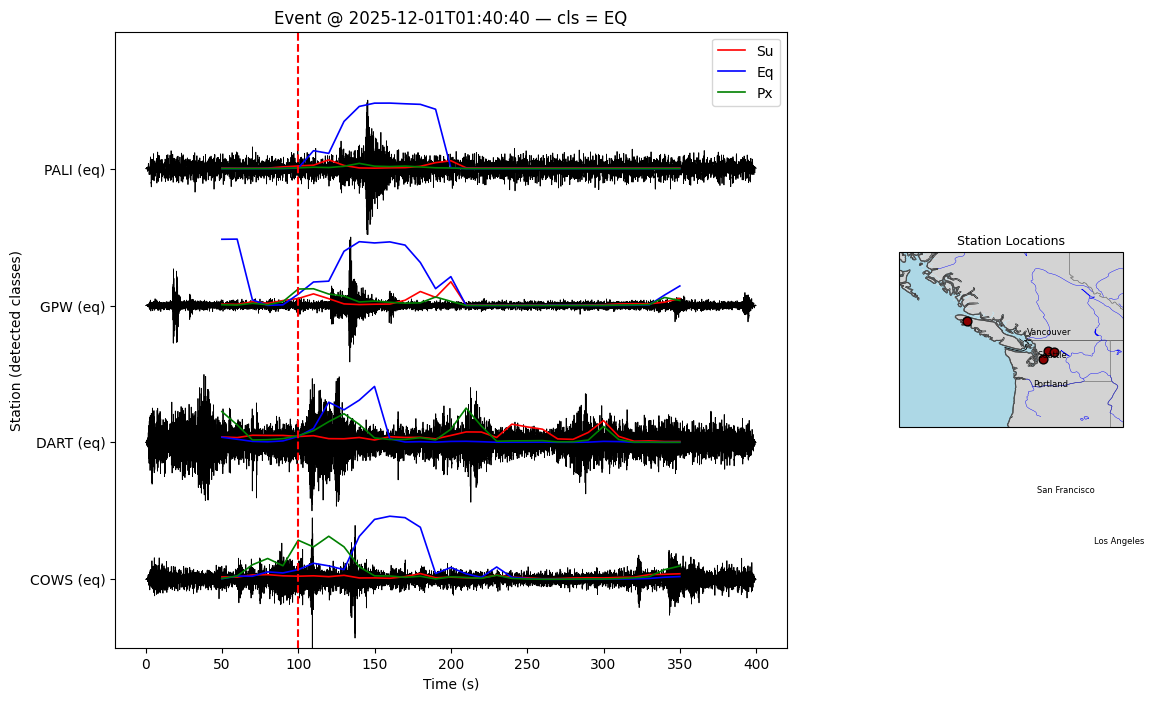

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


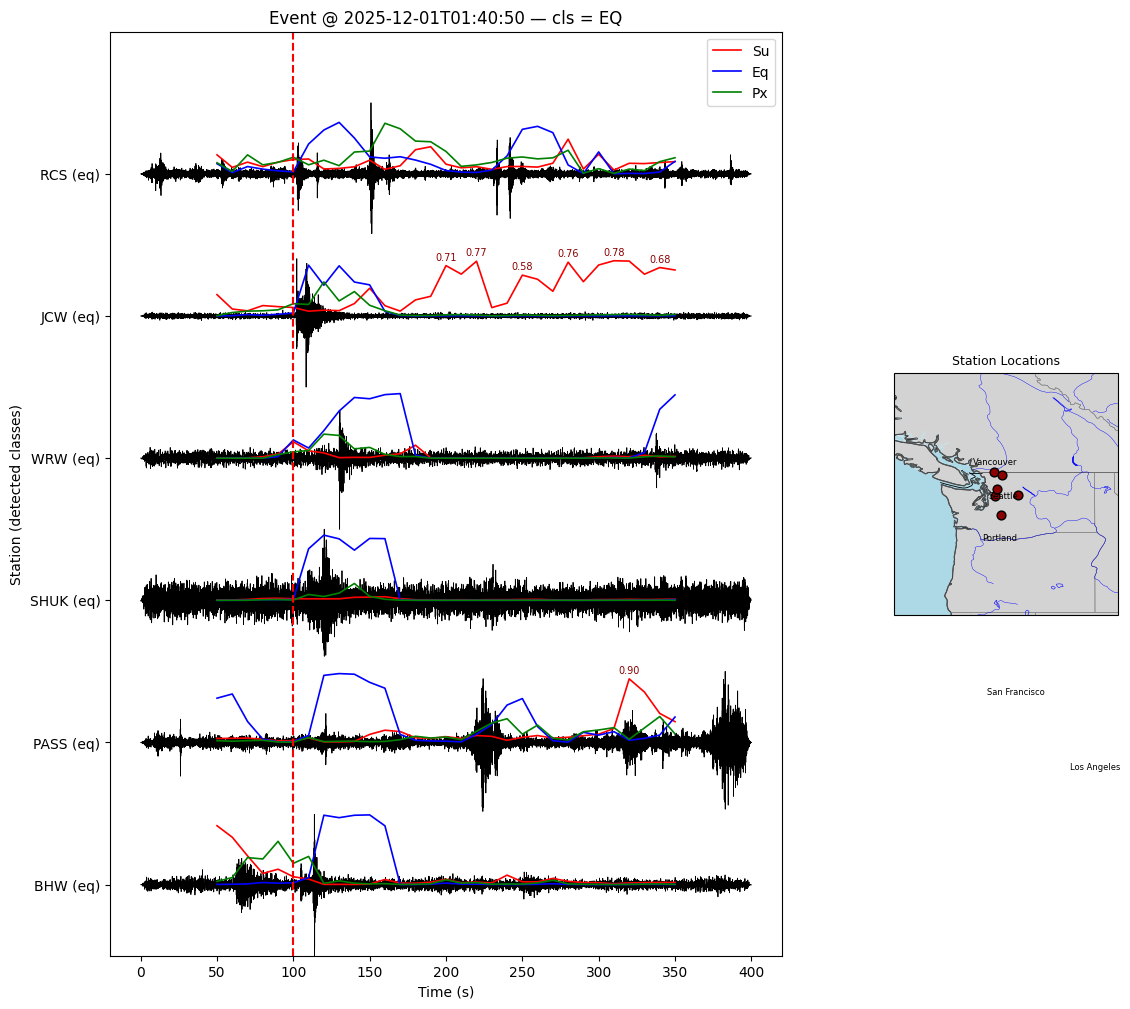

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


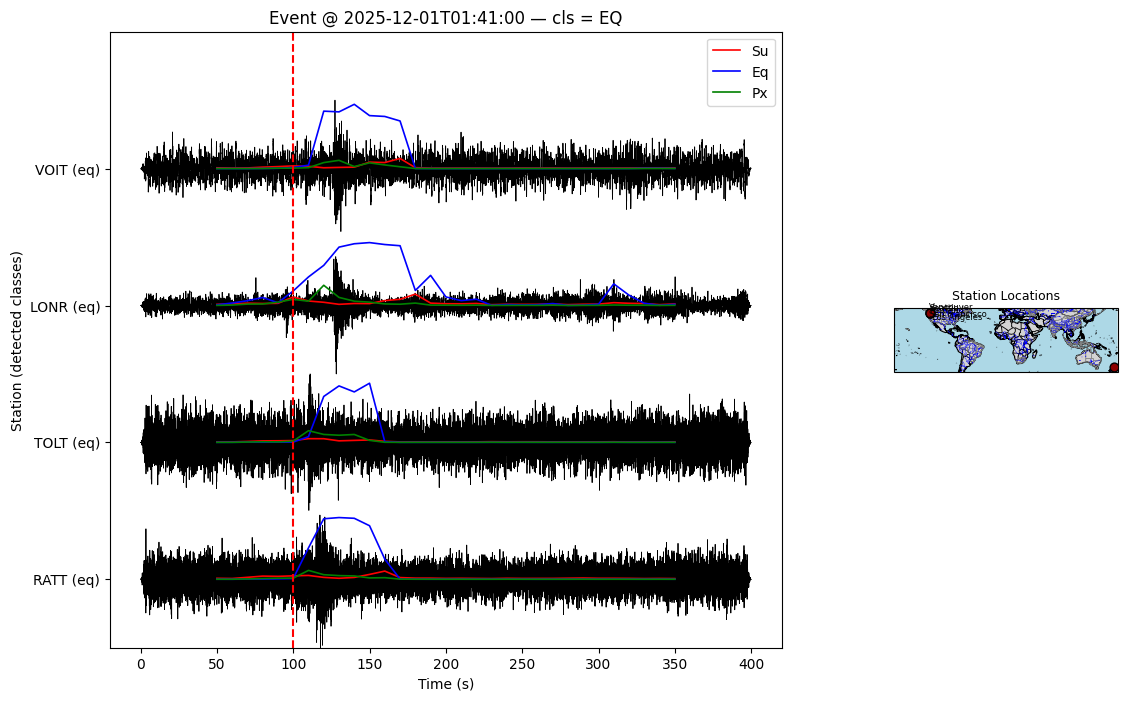

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


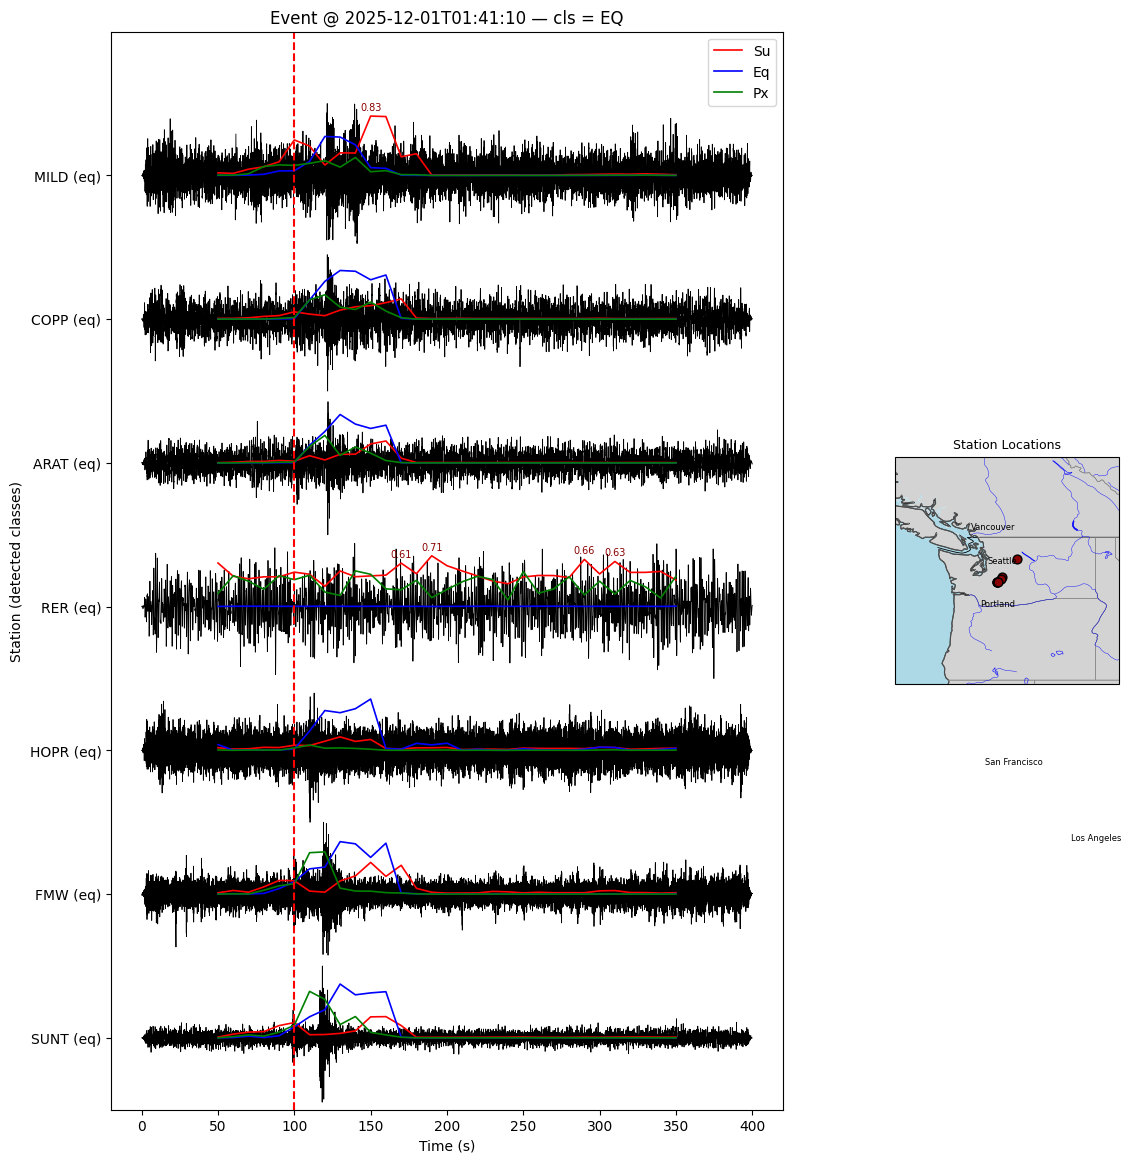

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


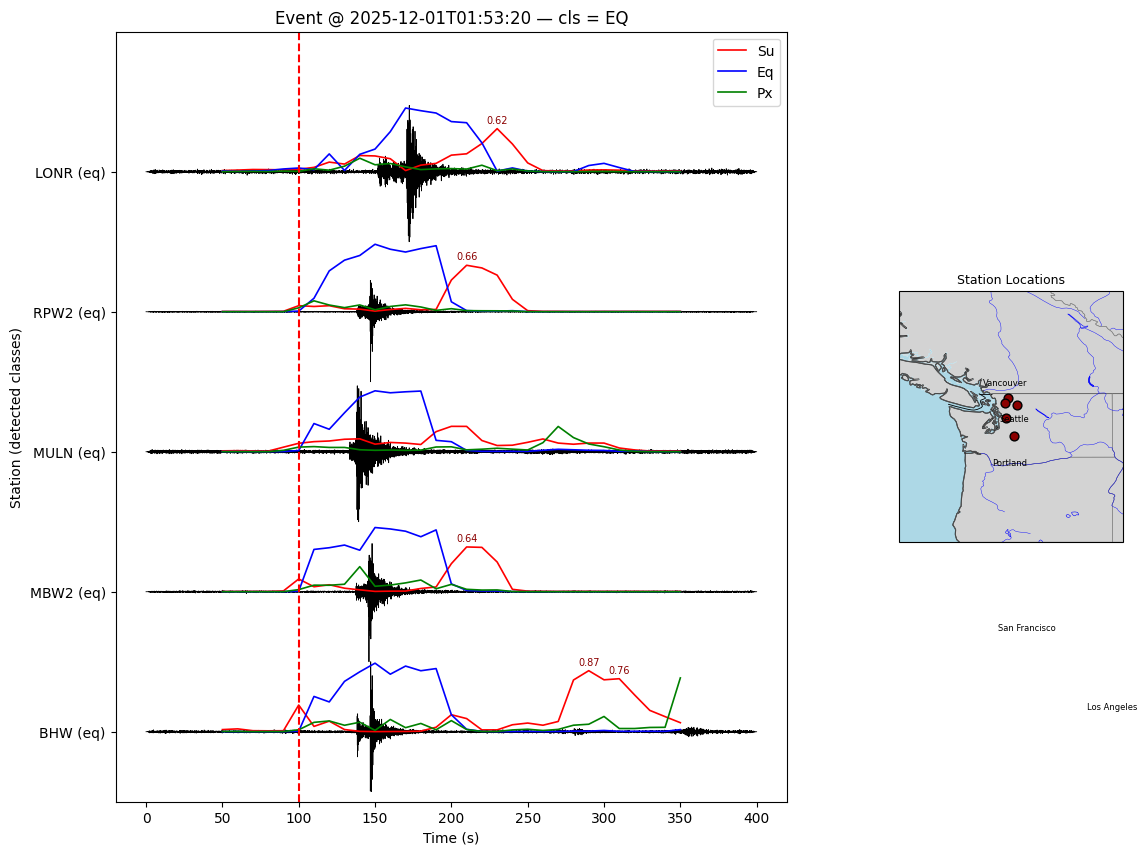

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


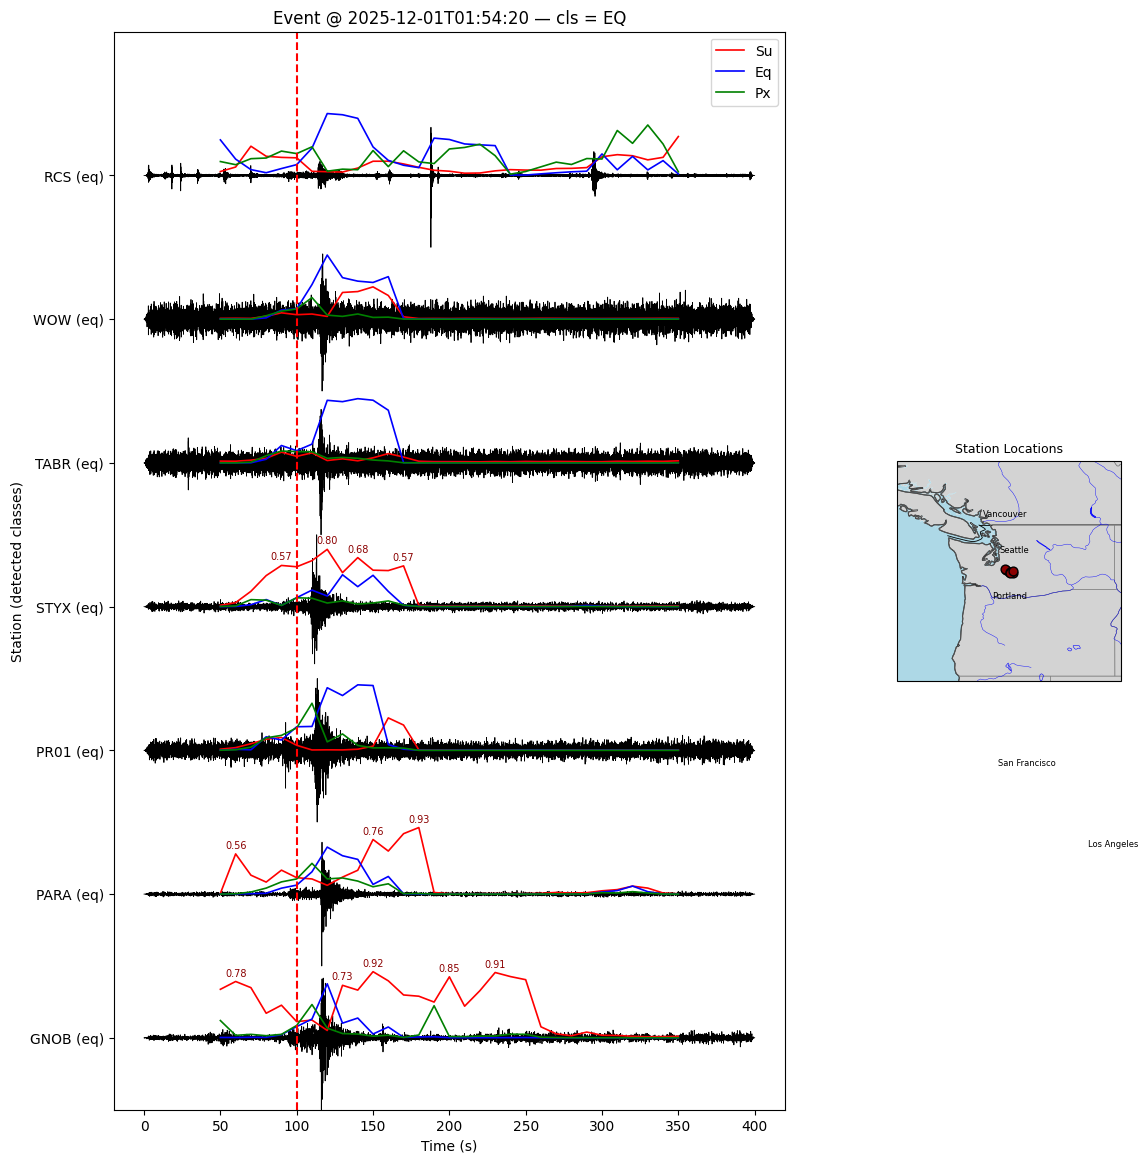

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


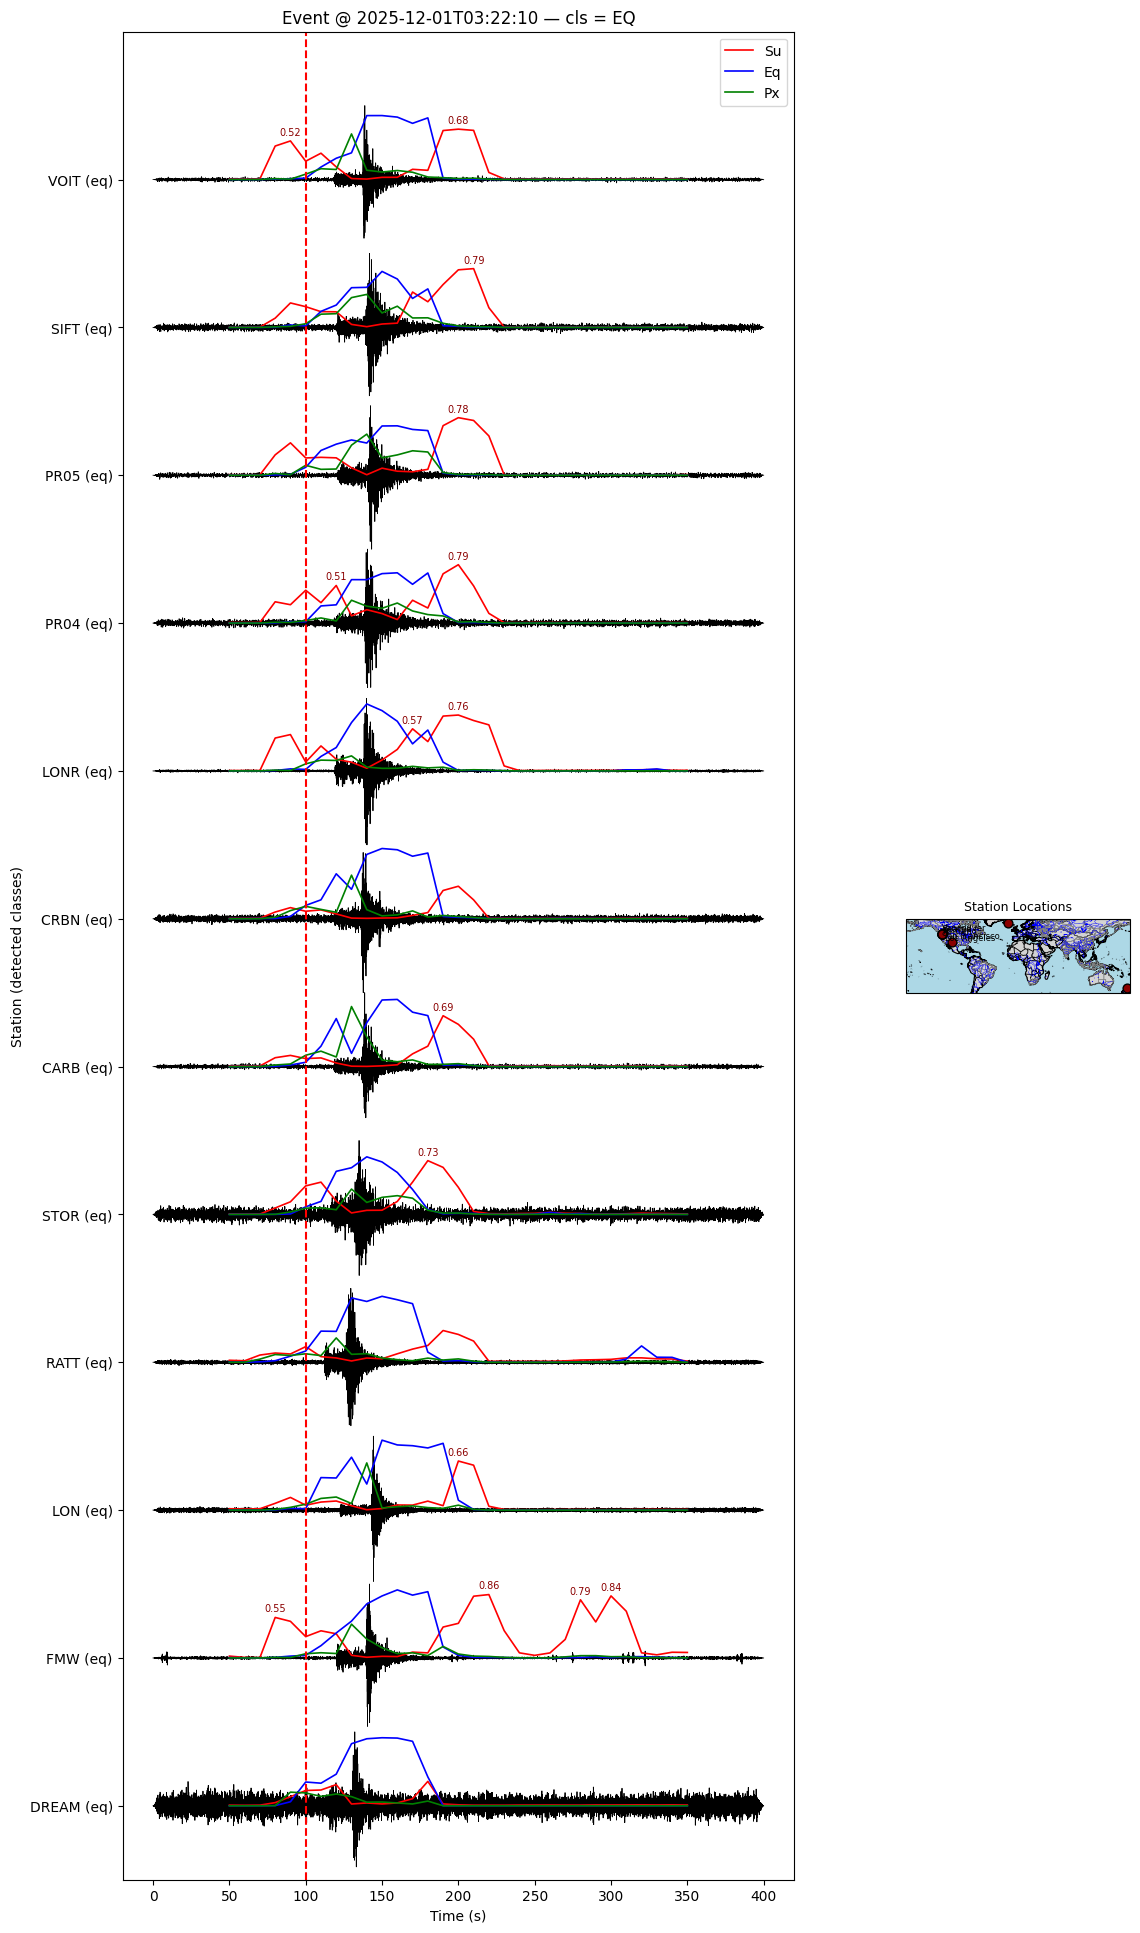

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


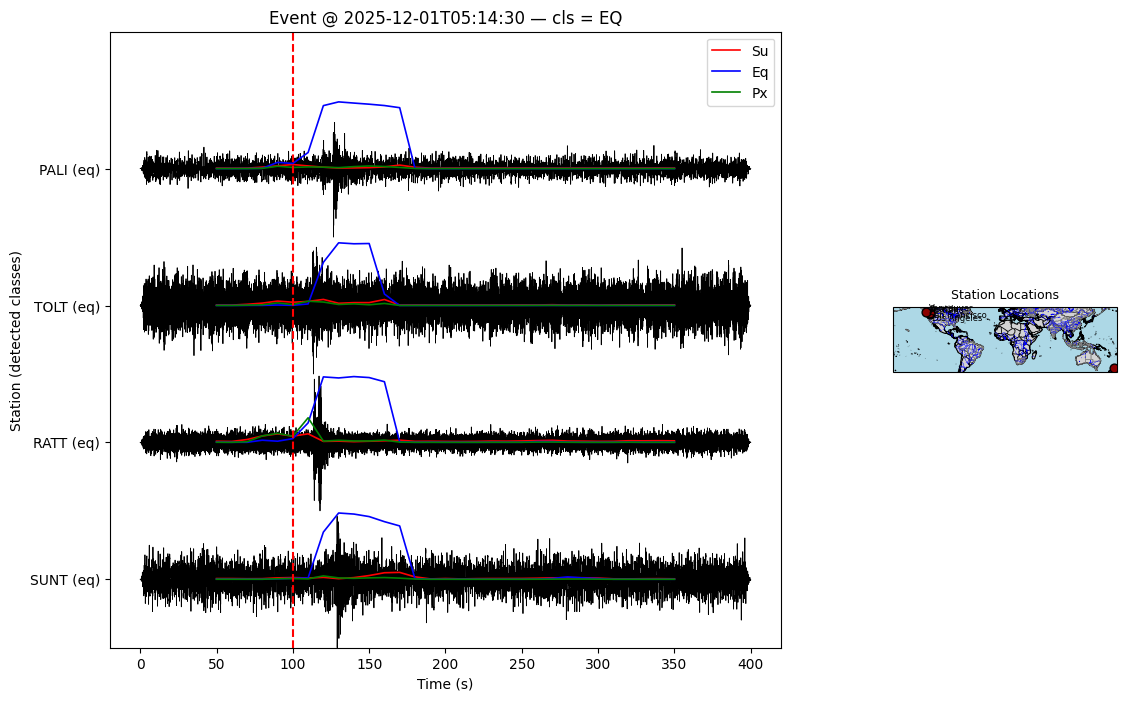

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


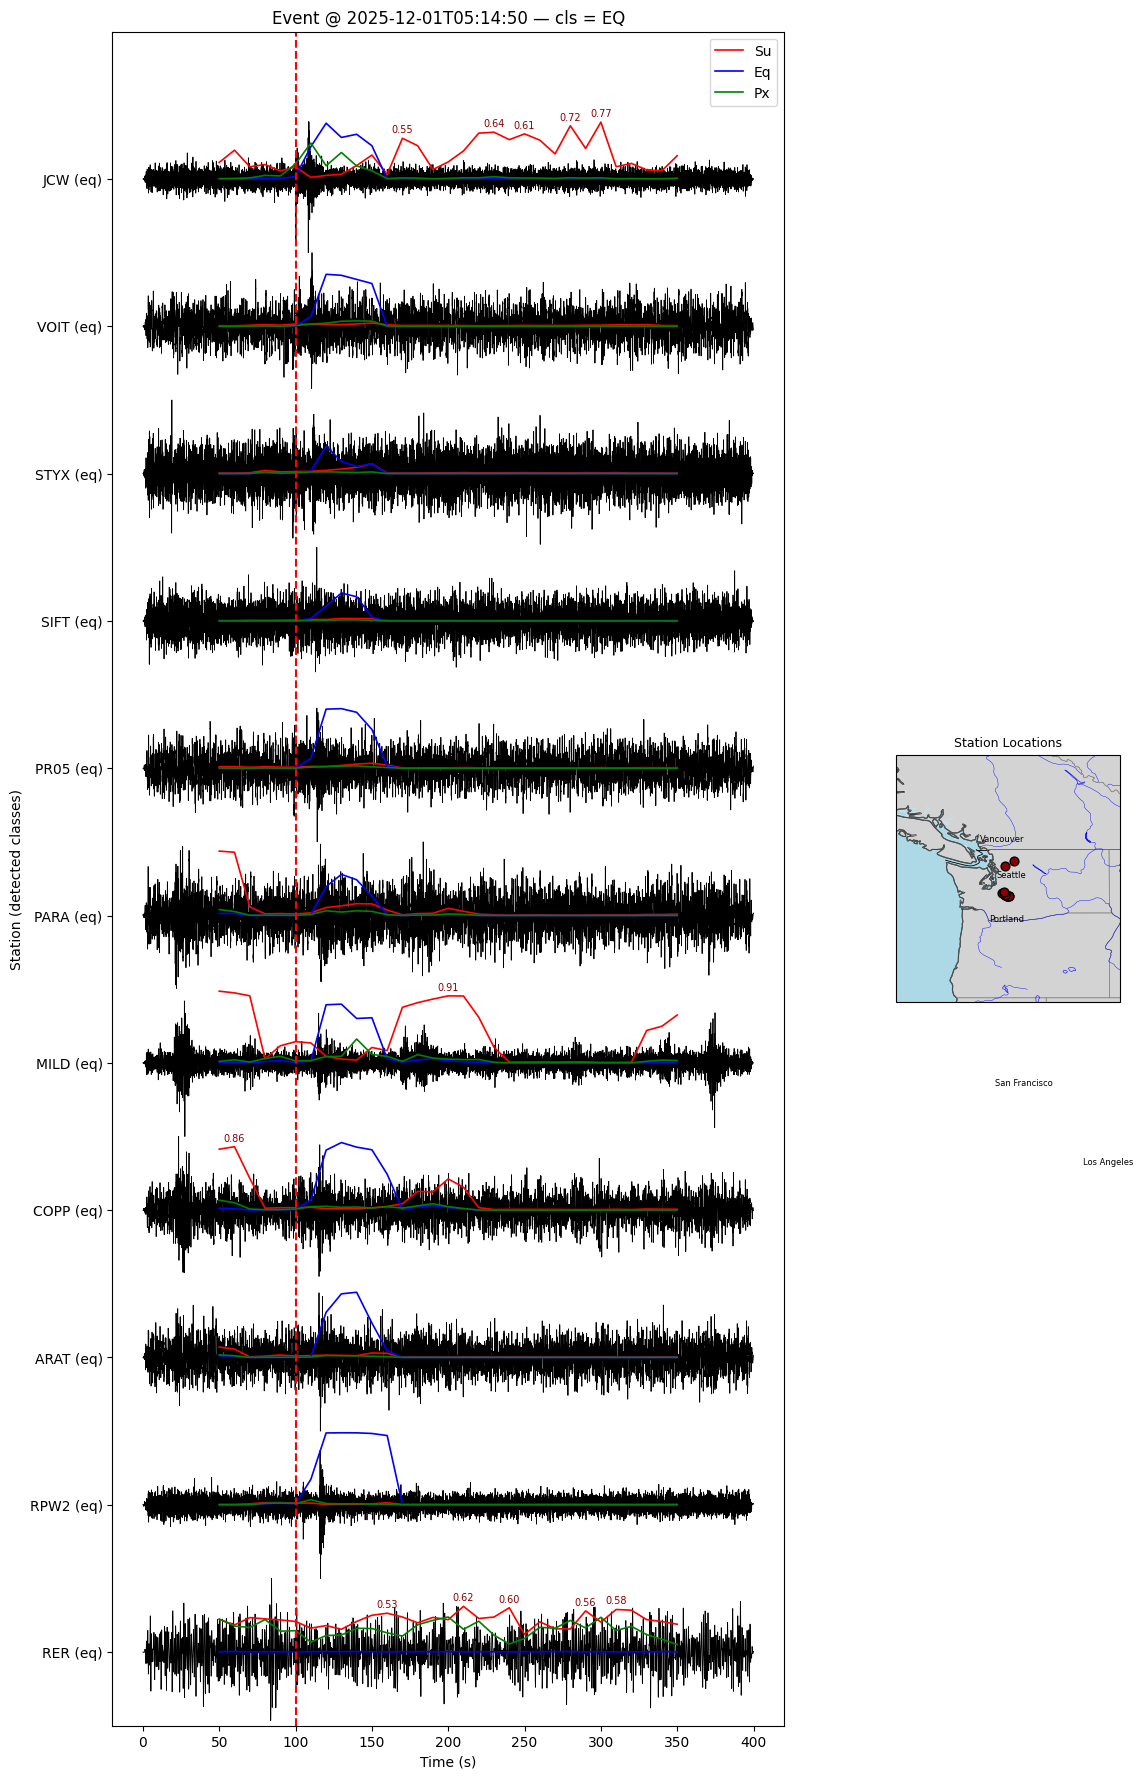

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


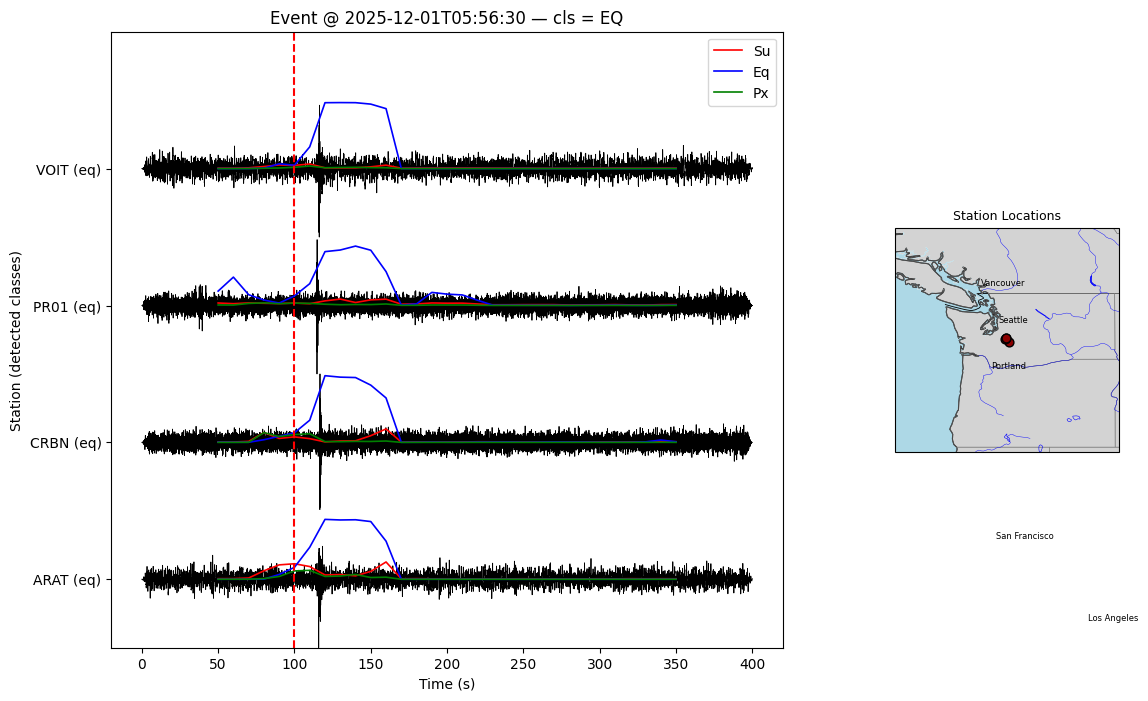

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


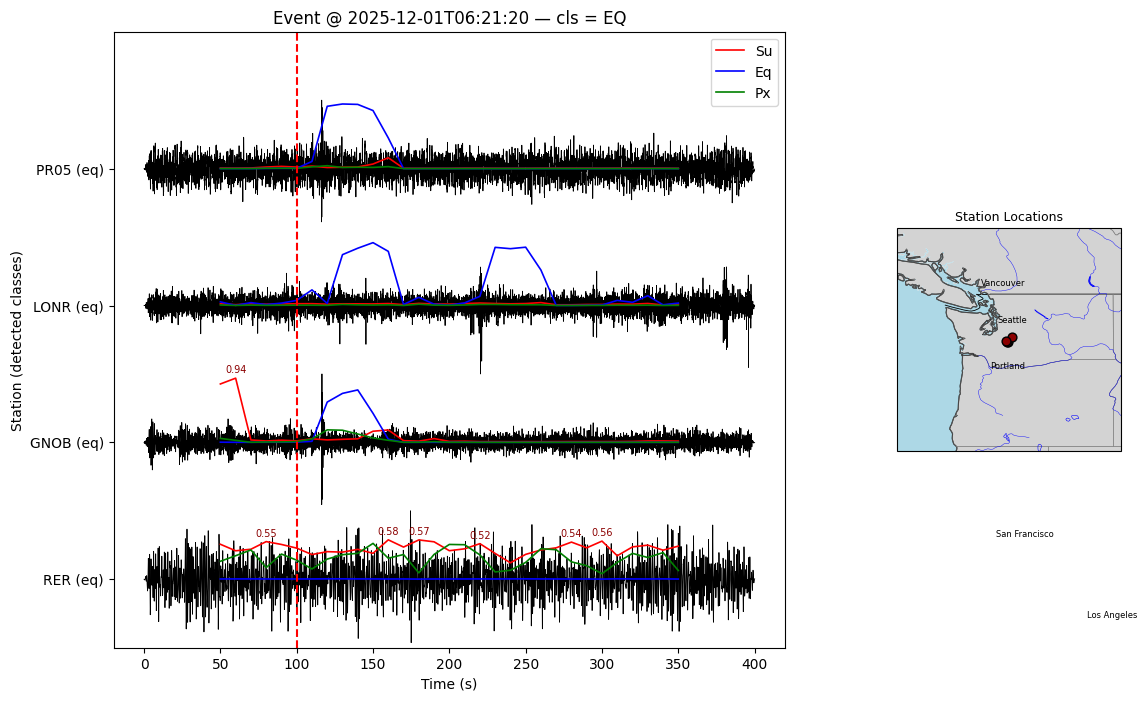

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


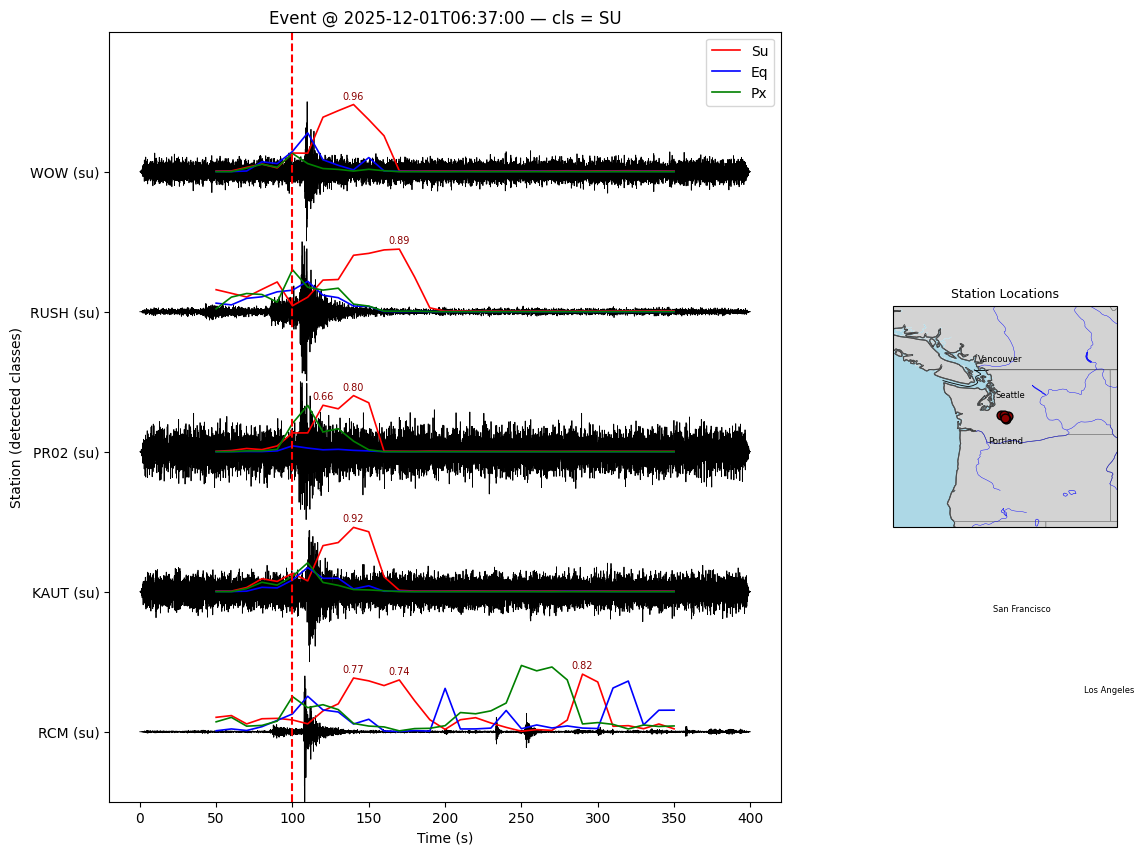

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


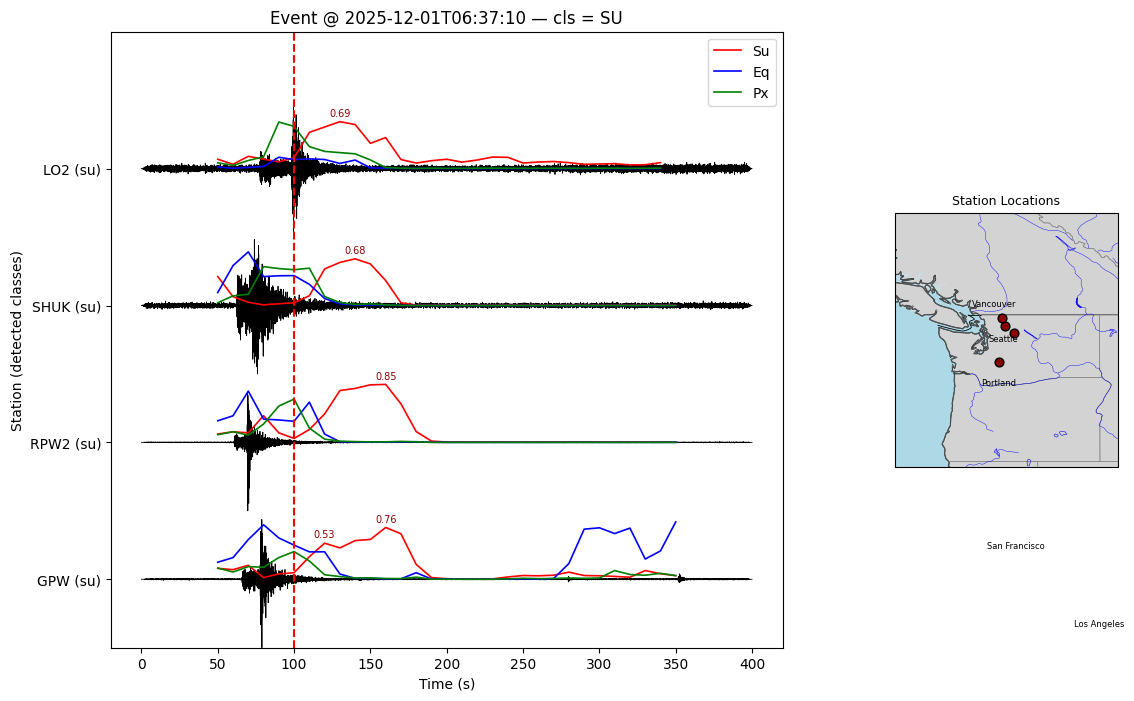

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


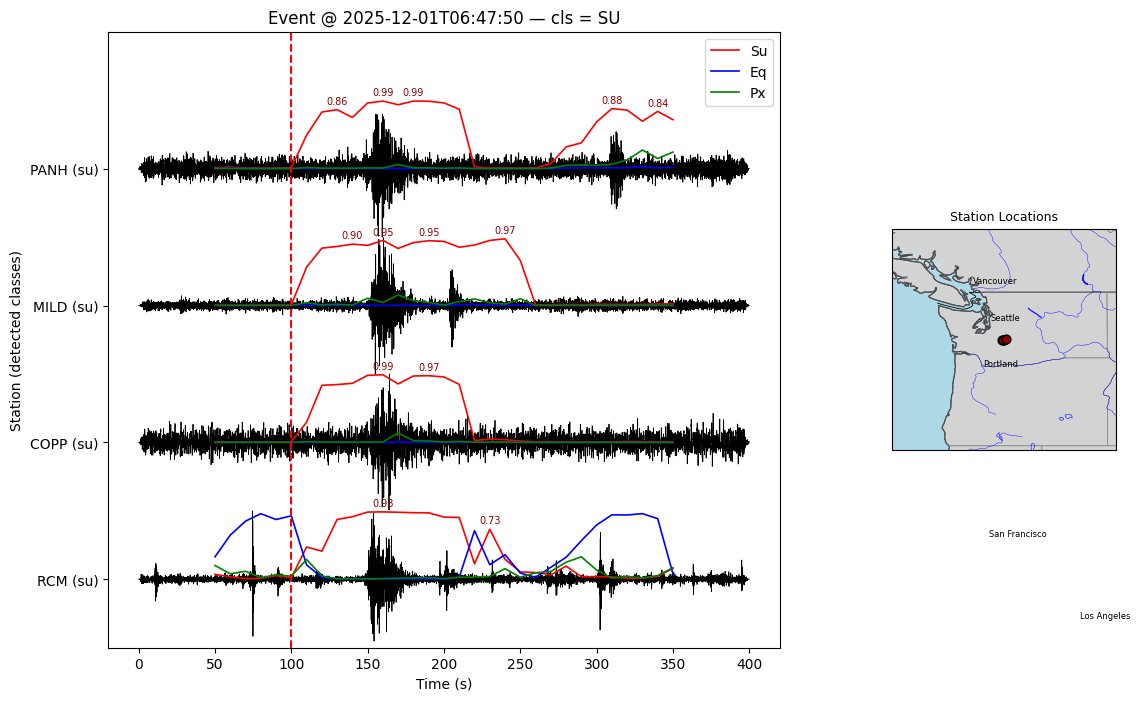

/tmp/ipykernel_3771478/3612480478.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


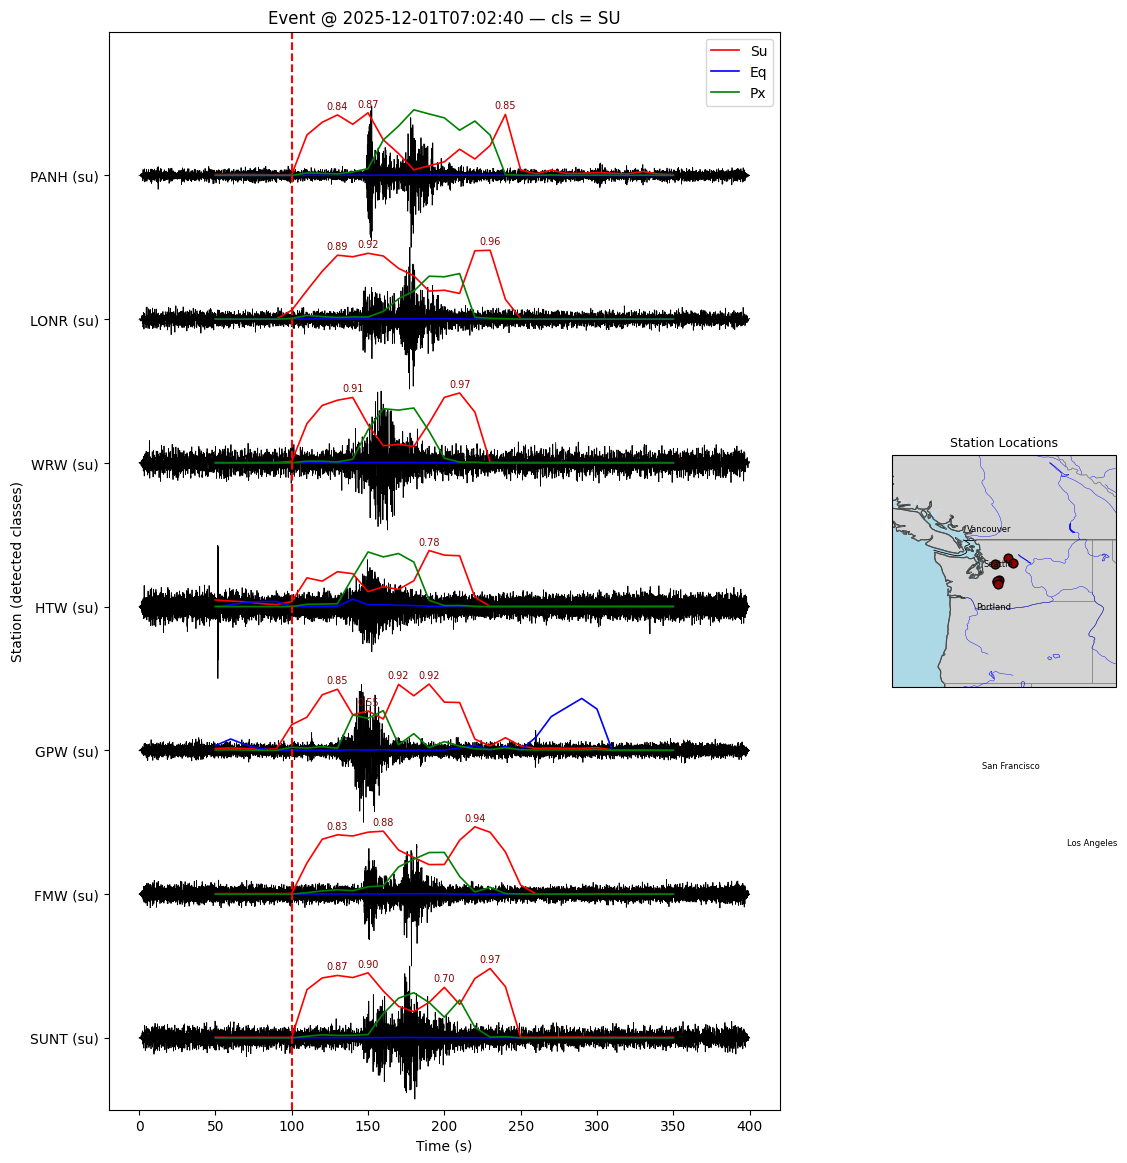

In [13]:
for i in range(20):#range(len(uniform_df)):
    plot_event_waveforms_general(uniform_df.iloc[i], duration= 300)


## Testing Kurtosis based picker

In [14]:
uniform_df

,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
4,2025-12-01 01:26:20+00:00,5,"['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']","[su, su, su, su, su]",su,21.986420,0.931628,0.607378
6,2025-12-01 01:26:50+00:00,5,"['SUNT', 'FMW', 'HTW', 'RPW2', 'RCS']","[su, su, su, su, su]",su,12.253034,0.847616,0.524463
7,2025-12-01 01:27:00+00:00,4,"['LOKMT', 'LON', 'COPP', 'PARA']","[su, su, su, su]",su,11.092132,0.827567,0.499348
15,2025-12-01 01:31:50+00:00,4,"['DREAM', 'HTW', 'CARB', 'CRBN']","[su, su, su, su]",su,3.366616,0.595179,0.381963
16,2025-12-01 01:38:20+00:00,4,"['RER', 'COPP', 'PANH', 'PARA']","[su, su, su, su]",su,4.657438,0.774589,0.457177
...,...,...,...,...,...,...,...,...
750,2025-12-16 19:54:50+00:00,4,"['GPW', 'SHUK', 'TOLT', 'WRW']","[eq, eq, eq, eq]",eq,3.623255,0.727162,0.417541
753,2025-12-16 23:39:30+00:00,6,"['LOKMT', 'PASS', 'COPP', 'PALI', 'RUSH', 'SIFT']","[px, px, px, px, px, px]",px,3.302078,0.603461,0.365670
754,2025-12-16 23:39:40+00:00,4,"['SUNT', 'LTY', 'TBLMT', 'LONR']","[px, px, px, px]",px,2.745279,0.569903,0.363640
756,2025-12-17 00:59:00+00:00,4,"['RCM', 'SHUK', 'MILD', 'OBSR']","[su, su, su, su]",su,6.698956,0.707501,0.397538


[UW.GPW.HHZ] pick @ 2025-12-01T01:29:13.900000Z  (t_rel=173.90s)
[UW.MANO.HHZ] no pick found (try lowering z_thr or increasing win_short_s).
[UW.NAC2.HHZ] pick @ 2025-12-01T01:25:41.180000Z  (t_rel=-38.82s)
[UW.TBLMT.HHZ] no pick found (try lowering z_thr or increasing win_short_s).
[UW.WRW.HHZ] pick @ 2025-12-01T01:27:36.070000Z  (t_rel=76.07s)


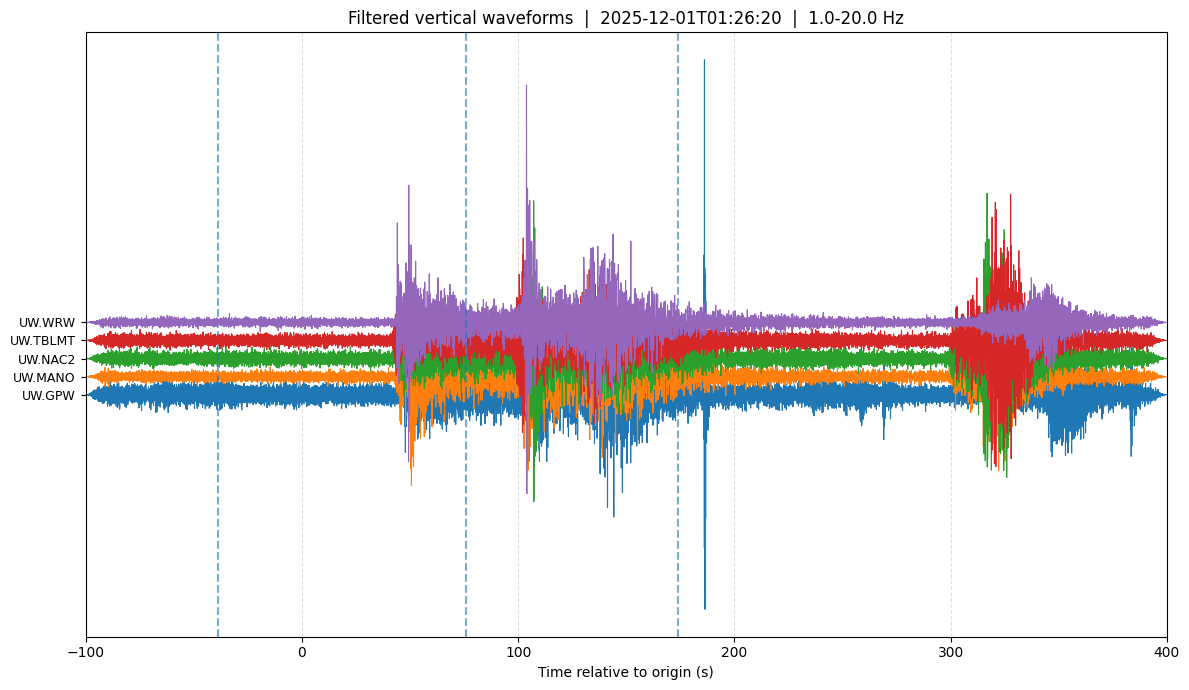

In [15]:
# --- Download vertical-component waveforms, run kurtosis picker, plot with picks ---
# Stations: ['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']
# Time window: 100 s before, 400 s after 2025-12-01 01:26:20+00:00

import numpy as np
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy import Stream


# -----------------------------
# Kurtosis picker (emergent-friendly)
# -----------------------------
def _rolling_kurtosis_trailing(x: np.ndarray, win: int) -> np.ndarray:
    """
    Trailing-window kurtosis (not excess). Output aligned so k[i] uses x[i-win+1:i+1].
    O(n) via running sums of moments.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    k = np.full(n, np.nan)
    if win < 4 or win > n:
        return k

    x1 = x
    x2 = x1 * x1
    x3 = x2 * x1
    x4 = x2 * x2

    c1 = np.cumsum(x1)
    c2 = np.cumsum(x2)
    c3 = np.cumsum(x3)
    c4 = np.cumsum(x4)

    def window_sum(c):
        return c[win - 1:] - np.concatenate(([0.0], c[:-win]))

    S1 = window_sum(c1)
    S2 = window_sum(c2)
    S3 = window_sum(c3)
    S4 = window_sum(c4)

    N = float(win)
    m1 = S1 / N
    ex2 = S2 / N
    ex3 = S3 / N
    ex4 = S4 / N

    mu2 = ex2 - m1**2
    # E[(x-m)^4]
    mu4 = ex4 - 4*m1*ex3 + 6*(m1**2)*ex2 - 4*(m1**3)*(S1/N) + (m1**4)

    eps = 1e-12
    kurt = mu4 / np.maximum(mu2, eps)**2
    k[win - 1:] = kurt
    return k


def kurtosis_picker_emergent(
    x: np.ndarray,
    fs: float,
    win_short_s: float = 0.5,
    win_long_s: float = 5.0,
    pre_s: float = 60.0,
    z_thr: float = 6.0,
    min_hold_s: float = 0.2,
    use_diff: bool = True,
):
    """
    Multi-scale kurtosis picker tuned for emergent arrivals.

    Returns:
      pick_idx (int or None), pick_time_sec (float or None), CF_z, CF
    """
    x = np.asarray(x, dtype=float)
    if x.size < int(fs * (win_long_s + 1)):
        return None, None, np.full_like(x, np.nan), np.full_like(x, np.nan)

    if use_diff:
        x = np.diff(x, prepend=x[0])

    ws = max(4, int(round(win_short_s * fs)))
    wl = max(ws + 1, int(round(win_long_s * fs)))

    Ks = _rolling_kurtosis_trailing(x, ws)
    Kl = _rolling_kurtosis_trailing(x, wl)
    CF = Ks - Kl

    pre_n = int(round(pre_s * fs))
    pre_n = min(pre_n, CF.size)
    baseline = CF[:pre_n]
    baseline = baseline[np.isfinite(baseline)]
    if baseline.size < 20:
        return None, None, np.full_like(CF, np.nan), CF

    med = np.median(baseline)
    mad = np.median(np.abs(baseline - med)) + 1e-12
    CF_z = 0.6745 * (CF - med) / mad

    hold_n = max(1, int(round(min_hold_s * fs)))
    above = (CF_z > z_thr) & np.isfinite(CF_z)

    run = np.convolve(above.astype(int), np.ones(hold_n, dtype=int), mode="same")
    candidates = np.where(run >= hold_n)[0]
    if candidates.size == 0:
        return None, None, CF_z, CF

    pick_idx = int(candidates[0])
    return pick_idx, pick_idx / fs, CF_z, CF


# -----------------------------
# Data download utilities
# -----------------------------
def choose_best_vertical_trace(st: Stream) -> Stream:
    """
    Pick one vertical component trace from a stream.
    Preference: HHZ > BHZ > EHZ > anything ending in Z.
    If multiple, choose highest sampling rate among preferred group.
    """
    if len(st) == 0:
        return st

    # keep only vertical-ish channels
    z_trs = [tr for tr in st if tr.stats.channel and tr.stats.channel.upper().endswith("Z")]
    if not z_trs:
        return Stream()

    pref_order = ["HHZ", "BHZ", "EHZ"]
    for ch in pref_order:
        candidates = [tr for tr in z_trs if tr.stats.channel.upper() == ch]
        if candidates:
            best = max(candidates, key=lambda tr: tr.stats.sampling_rate)
            return Stream(traces=[best])

    # fallback: any *Z, take highest fs
    best = max(z_trs, key=lambda tr: tr.stats.sampling_rate)
    return Stream(traces=[best])


def download_vertical(
    client: Client,
    station: str,
    t0: UTCDateTime,
    t1: UTCDateTime,
):
    """
    Attempt to find any network/channel for this station and download *HZ.
    Returns (trace_or_None, label_str).
    """
    try:
        inv = client.get_stations(
            station=station,
            channel="*HZ",
            starttime=t0,
            endtime=t1,
            level="channel",
        )
    except Exception as e:
        print(f"[{station}] inventory lookup failed: {e}")
        return None, None

    if len(inv.networks) == 0:
        print(f"[{station}] no inventory found for *HZ in window.")
        return None, None

    # collect all possible net/loc/chan codes
    requests = []
    for net in inv:
        for sta in net:
            for cha in sta:
                requests.append((net.code, sta.code, cha.location_code or "", cha.code))

    # Try downloading all, then select best vertical trace
    st_all = Stream()
    for net, sta, loc, cha in requests:
        try:
            st = client.get_waveforms(
                network=net,
                station=sta,
                location=loc if loc != "" else "*",
                channel=cha,
                starttime=t0,
                endtime=t1,
                attach_response=False,
            )
            st_all += st
        except Exception:
            continue

    st_all = st_all.merge(method=1, fill_value="interpolate")
    st_best = choose_best_vertical_trace(st_all)

    if len(st_best) == 0:
        print(f"[{station}] waveform download failed (no usable vertical trace).")
        return None, None

    tr = st_best[0]
    label = f"{tr.stats.network}.{tr.stats.station}.{tr.stats.location}.{tr.stats.channel}".replace("..", ".")
    return tr, label


# -----------------------------
# Main
# -----------------------------
stations = ["GPW", "MANO", "NAC2", "TBLMT", "WRW"]
event_time = UTCDateTime("2025-12-01T01:26:20Z")
t0 = event_time - 100
t1 = event_time + 400

client = Client("IRIS")  # EarthScope/IRIS FDSN

traces = []
labels = []
picks = []

# Picker settings (good starting point for emergent-ish arrivals)
# You can tweak these.
picker_kwargs = dict(
    win_short_s=0.6,
    win_long_s=6.0,
    pre_s=70.0,       # use most of the 100s pre-window as baseline
    z_thr=6.0,
    min_hold_s=0.2,
    use_diff=True,
)

# Filtering settings
fmin, fmax = 1.0, 20.0

for sta in stations:
    tr, lab = download_vertical(client, sta, t0, t1)
    if tr is None:
        continue

    # preprocess
    tr = tr.copy()
    tr.detrend("linear")
    tr.taper(0.02)
    tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    # ensure uniform sample rate within each trace (optional)
    fs = float(tr.stats.sampling_rate)

    # run picker on filtered data
    x = tr.data.astype(np.float64)
    pick_idx, pick_t_sec, CF_z, CF = kurtosis_picker_emergent(x, fs=fs, **picker_kwargs)

    if pick_idx is None:
        pick_abs = None
        print(f"[{lab}] no pick found (try lowering z_thr or increasing win_short_s).")
    else:
        pick_abs = tr.stats.starttime + (pick_idx / fs)
        print(f"[{lab}] pick @ {pick_abs}  (t_rel={pick_abs - event_time:.2f}s)")

    traces.append(tr)
    labels.append(lab)
    picks.append(pick_abs)

# -----------------------------
# Plot: stacked filtered waveforms with picks
# -----------------------------
if len(traces) == 0:
    raise RuntimeError("No traces downloaded. Check station codes, time window, or data availability.")

# Align on event_time for plotting
plt.figure(figsize=(12, 7))
offset = 0
yticks = []
yticklabels = []

for k, (tr, lab, pk) in enumerate(zip(traces, labels, picks)):
    fs = float(tr.stats.sampling_rate)
    n = tr.stats.npts
    t = np.arange(n) / fs
    # Convert to relative time from event_time
    t_rel = (tr.stats.starttime - event_time) + t

    # Normalize each trace for display (optional)
    x = tr.data.astype(float)
    scale = np.nanstd(x) if np.nanstd(x) > 0 else 1.0
    x = x / scale

    y = x + offset
    plt.plot(t_rel, y, lw=0.8)

    # pick marker
    if pk is not None:
        pk_rel = pk - event_time
        plt.axvline(pk_rel, ymin=0, ymax=1, linestyle="--", alpha=0.6)
        plt.scatter([pk_rel], [offset], s=20)

    yticks.append(offset)
    # show just NET.STA on y-axis (privacy + compact)
    net_sta = ".".join(lab.split(".")[:2]) if "." in lab else lab
    yticklabels.append(net_sta)

    offset += 1.5  # vertical spacing

plt.title(f"{title if 'title' in globals() else 'Filtered vertical waveforms'}  |  {event_time.isoformat()}  |  {fmin}-{fmax} Hz")
plt.xlabel("Time relative to origin (s)")
plt.yticks(yticks, yticklabels, fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(-100, 400)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np

def spectrogram_energy_1d(x, fs, fmin=1.0, fmax=20.0, win_s=1.0, hop_s=0.1):
    """
    Compute a spectrogram, then collapse to 1D by summing log-power over frequency.
    Returns: t_spec (seconds), e (1D energy series)
    """
    from scipy.signal import spectrogram

    x = np.asarray(x, dtype=float)
    nperseg = max(16, int(round(win_s * fs)))
    noverlap = max(0, nperseg - int(round(hop_s * fs)))
    noverlap = min(noverlap, nperseg - 1)

    f, t, Sxx = spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
        mode="psd",
    )

    # band-limit the spectrogram before collapsing
    band = (f >= fmin) & (f <= fmax)
    if not np.any(band):
        # fallback: use all freqs
        band = slice(None)

    eps = 1e-20
    logp = np.log10(Sxx[band, :] + eps)  # log-power stabilizes variance
    e = np.sum(logp, axis=0)             # your idea: sum over frequency

    # light smoothing helps a lot
    # (moving average over ~0.3s)
    smooth_s = 0.3
    k = max(1, int(round(smooth_s / max(hop_s, 1e-6))))
    if k > 1:
        e = np.convolve(e, np.ones(k)/k, mode="same")

    return t, e


In [17]:
def _rolling_kurtosis_trailing(x: np.ndarray, win: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    n = x.size
    k = np.full(n, np.nan)
    if win < 4 or win > n:
        return k

    x1 = x
    x2 = x1 * x1
    x3 = x2 * x1
    x4 = x2 * x2

    c1 = np.cumsum(x1)
    c2 = np.cumsum(x2)
    c3 = np.cumsum(x3)
    c4 = np.cumsum(x4)

    def window_sum(c):
        return c[win - 1:] - np.concatenate(([0.0], c[:-win]))

    S1 = window_sum(c1)
    S2 = window_sum(c2)
    S3 = window_sum(c3)
    S4 = window_sum(c4)

    N = float(win)
    m1 = S1 / N
    ex2 = S2 / N
    ex3 = S3 / N
    ex4 = S4 / N

    mu2 = ex2 - m1**2
    mu4 = ex4 - 4*m1*ex3 + 6*(m1**2)*ex2 - 4*(m1**3)*(S1/N) + (m1**4)

    eps = 1e-12
    kurt = mu4 / np.maximum(mu2, eps)**2
    k[win - 1:] = kurt
    return k


def kurtosis_picker_on_energy(e, dt,
                             win_short_s=2.0, win_long_s=20.0,
                             pre_s=60.0,
                             z_thr=4.0, min_hold_s=0.6):
    """
    e: 1D energy series
    dt: sampling interval of energy series (e.g., hop_s)
    Returns: pick_index, pick_time_sec, CF_z, CF
    """
    e = np.asarray(e, dtype=float)

    ws = max(4, int(round(win_short_s / dt)))
    wl = max(ws + 1, int(round(win_long_s / dt)))

    Ks = _rolling_kurtosis_trailing(e, ws)
    Kl = _rolling_kurtosis_trailing(e, wl)
    CF = Ks - Kl

    pre_n = min(len(CF), int(round(pre_s / dt)))
    base = CF[:pre_n]
    base = base[np.isfinite(base)]
    if base.size < 20:
        return None, None, np.full_like(CF, np.nan), CF

    med = np.median(base)
    mad = np.median(np.abs(base - med)) + 1e-12
    CF_z = 0.6745 * (CF - med) / mad

    hold_n = max(1, int(round(min_hold_s / dt)))
    above = (CF_z > z_thr) & np.isfinite(CF_z)
    run = np.convolve(above.astype(int), np.ones(hold_n, dtype=int), mode="same")
    cand = np.where(run >= hold_n)[0]
    if cand.size == 0:
        return None, None, CF_z, CF

    pick_idx = int(cand[0])
    return pick_idx, pick_idx * dt, CF_z, CF


In [18]:
# After you filter the trace (tr.data), do:
fs = float(tr.stats.sampling_rate)
x = tr.data.astype(float)

# Build 1D energy series from spectrogram
t_spec, e = spectrogram_energy_1d(
    x, fs,
    fmin=1.0, fmax=20.0,
    win_s=1.5, hop_s=0.1
)

dt = t_spec[1] - t_spec[0] if len(t_spec) > 1 else 0.1

# Pick on energy
pick_i, pick_t_energy, CFz, CF = kurtosis_picker_on_energy(
    e, dt,
    win_short_s=3.0,
    win_long_s=25.0,
    pre_s=60.0,      # baseline from early part of your window
    z_thr=4.0,
    min_hold_s=0.8
)

if pick_i is None:
    pick_abs = None
else:
    pick_abs = tr.stats.starttime + float(pick_t_energy)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# -----------------------------
# Spectrogram + 1D energy (same spectrogram used for BOTH pick + plot)
# -----------------------------
def compute_spectrogram_and_energy(
    x, fs,
    fmin=1.0, fmax=20.0,
    win_s=1.5, hop_s=0.1
):
    """
    Returns:
      f (Hz), t (s from trace start), Sxx (PSD), e (1D energy series), band_mask
    """
    x = np.asarray(x, dtype=float)

    nperseg  = max(16, int(round(win_s * fs)))
    hop_n    = max(1,  int(round(hop_s * fs)))
    noverlap = max(0, nperseg - hop_n)
    noverlap = min(noverlap, nperseg - 1)

    f, t, Sxx = spectrogram(
        x, fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
        mode="psd",
    )

    band = (f >= fmin) & (f <= fmax)
    if not np.any(band):
        band = np.ones_like(f, dtype=bool)

    # Your idea: collapse spectrogram to 1D by summing over frequency
    # Use log-power to stabilize variance
    eps = 1e-20
    logp = np.log10(Sxx[band, :] + eps)
    e = np.sum(logp, axis=0)

    # Light smoothing in spectrogram-time domain helps robustness
    k = max(1, int(round(0.3 / max(hop_s, 1e-6))))  # ~0.3s smoothing
    if k > 1:
        e = np.convolve(e, np.ones(k)/k, mode="same")

    return f, t, Sxx, e, band


# -----------------------------
# Multi-scale kurtosis picker on 1D energy
# -----------------------------
def _rolling_kurtosis_trailing(x: np.ndarray, win: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    n = x.size
    out = np.full(n, np.nan)
    if win < 4 or win > n:
        return out

    x1 = x
    x2 = x1 * x1
    x3 = x2 * x1
    x4 = x2 * x2

    c1 = np.cumsum(x1)
    c2 = np.cumsum(x2)
    c3 = np.cumsum(x3)
    c4 = np.cumsum(x4)

    def window_sum(c):
        return c[win - 1:] - np.concatenate(([0.0], c[:-win]))

    S1 = window_sum(c1)
    S2 = window_sum(c2)
    S3 = window_sum(c3)
    S4 = window_sum(c4)

    N = float(win)
    m1  = S1 / N
    ex2 = S2 / N
    ex3 = S3 / N
    ex4 = S4 / N

    mu2 = ex2 - m1**2
    mu4 = ex4 - 4*m1*ex3 + 6*(m1**2)*ex2 - 4*(m1**3)*(S1/N) + (m1**4)

    eps = 1e-12
    k = mu4 / np.maximum(mu2, eps)**2
    out[win - 1:] = k
    return out


def kurtosis_picker_on_energy(
    e, dt,
    win_short_s=3.0,
    win_long_s=25.0,
    pre_s=60.0,
    z_thr=4.0,
    min_hold_s=0.8,
):
    e = np.asarray(e, dtype=float)

    ws = max(4, int(round(win_short_s / dt)))
    wl = max(ws + 1, int(round(win_long_s / dt)))

    Ks = _rolling_kurtosis_trailing(e, ws)
    Kl = _rolling_kurtosis_trailing(e, wl)
    CF = Ks - Kl

    pre_n = min(len(CF), int(round(pre_s / dt)))
    base = CF[:pre_n]
    base = base[np.isfinite(base)]
    if base.size < 20:
        return None, None, np.full_like(CF, np.nan), CF

    med = np.median(base)
    mad = np.median(np.abs(base - med)) + 1e-12
    CF_z = 0.6745 * (CF - med) / mad

    hold_n = max(1, int(round(min_hold_s / dt)))
    above = (CF_z > z_thr) & np.isfinite(CF_z)
    run = np.convolve(above.astype(int), np.ones(hold_n, dtype=int), mode="same")
    cand = np.where(run >= hold_n)[0]
    if cand.size == 0:
        return None, None, CF_z, CF

    pick_i = int(cand[0])
    return pick_i, pick_i * dt, CF_z, CF


# -----------------------------
# Plot spectrograms with picks (for multiple stations)
# -----------------------------
def plot_spectrograms_with_picks(
    traces, labels, picks_abs, event_time,
    fmin=1.0, fmax=20.0,
    win_s=1.5, hop_s=0.1,
    tmin=-100, tmax=400,
):
    """
    traces: list of ObsPy Trace (already filtered if you want)
    picks_abs: list of UTCDateTime or None
    """
    n = len(traces)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6*n), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, tr, lab, pk in zip(axes, traces, labels, picks_abs):
        fs = float(tr.stats.sampling_rate)
        x = tr.data.astype(float)

        f, t, Sxx, e, band = compute_spectrogram_and_energy(
            x, fs, fmin=fmin, fmax=fmax, win_s=win_s, hop_s=hop_s
        )

        # Convert time axis to "relative to origin (event_time)"
        t_rel = (tr.stats.starttime - event_time) + t

        # Plot log10 power
        eps = 1e-20
        logS = np.log10(Sxx + eps)

        # limit freq display
        fmask = (f >= fmin) & (f <= fmax)
        ax.pcolormesh(t_rel, f[fmask], logS[fmask, :], shading="auto")

        # Origin line at t=0
        ax.axvline(0.0, linestyle="--", linewidth=1, color = 'red')

        # Pick line
        if pk is not None:
            pk_rel = float(pk - event_time)
            ax.axvline(pk_rel, linestyle="-", linewidth=1.5)

        ax.set_ylabel("Hz")
        ax.set_title(lab)

    axes[-1].set_xlabel("Time relative to origin (s)")
    axes[-1].set_xlim(tmin, tmax)
    axes[0].set_ylim(fmin, fmax)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_spectrograms_with_picks(traces, labels, picks, event_time,
                            fmin=1.0, fmax=20.0, win_s=1.5, hop_s=0.1,
                            tmin=-100, tmax=400)


# Visualizing the picks

## Loading various pretrained picking models

In [23]:
# Various pre-trained weights for PhaseNet
# pn_model = sbm.PhaseNet.from_pretrained("ethz")
# pn_model = sbm.PhaseNet.from_pretrained("instance")
# pn_model = sbm.PhaseNet.from_pretrained("scedc")
pn_model = sbm.PhaseNet.from_pretrained("stead")
# pn_model = sbm.PhaseNet.from_pretrained("geofon")
# pn_model = sbm.PhaseNet.from_pretrained("neic")

# Various pre-trained weights for EQT
eqt_model = sbm.EQTransformer.from_pretrained("original")
#eqt_model = sbm.EQTransformer.from_pretrained("ethz")
# eqt_model = sbm.EQTransformer.from_pretrained("instance")
#eqt_model = sbm.EQTransformer.from_pretrained("scedc")
# eqt_model = sbm.EQTransformer.from_pretrained("stead")
# eqt_model = sbm.EQTransformer.from_pretrained("geofon")

# Various pre-trained weights for GPD
# gpd_model = sbm.GPD.from_pretrained("original")
# gpd_model = sbm.GPD.from_pretrained("ethz")
# gpd_model = sbm.GPD.from_pretrained("scedc")
gpd_model = sbm.GPD.from_pretrained("stead")
# gpd_model = sbm.GPD.from_pretrained("geofon")
# gpd_model = sbm.GPD.from_pretrained("neic")

In [24]:
def plot_event_waveforms_and_picks(event_row, duration=300, peak_thresh=0.50, model = gpd_model):
    client      = Client("IRIS")
    event_time  = UTCDateTime(pd.to_datetime(event_row["rounded_start"]).to_pydatetime())
    stations    = ast.literal_eval(event_row["stations"])
    target_cls  = event_row["most_common_class"]

    fig, ax = plt.subplots(figsize=(10, 2 * len(stations)))

    y_offsets = []
    for i, sta in enumerate(stations):
        try:
            st = client.get_waveforms("*", sta, "*", "*HZ",
                                      starttime=event_time,
                                      endtime=event_time + duration)
            st.resample(50)
            

            # ── inference ───────────────────────────────────────────────
            probs_st = model.annotate(st)
            

        
            probs_tr_0 = probs_st[0]
            probs_tr_1 = probs_st[1]
            probs_tr_2 = probs_st[2]
            
            t_probs  = probs_tr_0.times() 
            
            
            d_probs_0  = probs_tr_0.data*2
            d_probs_1 = probs_tr_1.data*2
            d_probs_2 = probs_tr_2.data*2

            # ── waveform prep ───────────────────────────────────────────
            st.detrend("linear"); st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)
            tr       = st[0]
            t_wave   = tr.times("relative")
            y_wave   = tr.data / np.abs(tr.data).max()

            # ── plot ────────────────────────────────────────────────────
            offset = 2 * i
            y_offsets.append(offset)
            ax.plot(t_wave,  y_wave + offset,  lw=0.6, color="black")
            
            
            t_max = t_wave[np.argmax(y_wave+offset)]
         
            ax.plot(t_probs, d_probs_0 + offset, lw=1.2, color = 'orange')
            ax.plot(t_probs, d_probs_1 + offset, lw=1.2, color = 'blue')
            ax.plot(t_probs, d_probs_2 + offset, lw=1.2, color = 'green')

            # annotate peaks above threshold
            """
            peaks = np.where((d_probs[1:-1] > d_probs[:-2]) &
                             (d_probs[1:-1] > d_probs[2:]) &
                             (d_probs[1:-1] >= peak_thresh))[0] + 1
            for p in peaks:
                ax.text(t_probs[p], d_probs[p] + offset + 0.05,
                        f"{d_probs[p]:.2f}", ha="center", va="bottom",
                        fontsize=7, color="darkblue")
            """
        except Exception as e:
            print(f"❌ {sta}: {e}")

    # ── styling ────────────────────────────────────────────────────────
    ax.axvline(0, color="red", ls="--")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}")

    # put station names on y-axis at the row centers
    #ax.set_yticks(y_offsets)
    #ax.set_yticklabels(stations)
    ax.set_ylabel("Station")

    #ax.set_xlim( t_max - 50, t_max + 50)
    #ax.set_ylim(-1, 2 * len(stations))
    plt.tight_layout()
    plt.show()


In [29]:
uniform_df.head()

,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
4,2025-12-01 01:26:20+00:00,5,"['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']","[su, su, su, su, su]",su,21.986420,0.931628,0.607378
6,2025-12-01 01:26:50+00:00,5,"['SUNT', 'FMW', 'HTW', 'RPW2', 'RCS']","[su, su, su, su, su]",su,12.253034,0.847616,0.524463
7,2025-12-01 01:27:00+00:00,4,"['LOKMT', 'LON', 'COPP', 'PARA']","[su, su, su, su]",su,11.092132,0.827567,0.499348
15,2025-12-01 01:31:50+00:00,4,"['DREAM', 'HTW', 'CARB', 'CRBN']","[su, su, su, su]",su,3.366616,0.595179,0.381963
16,2025-12-01 01:38:20+00:00,4,"['RER', 'COPP', 'PANH', 'PARA']","[su, su, su, su]",su,4.657438,0.774589,0.457177


In [50]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from obspy.clients.fdsn import Client


def plot_event_waveforms_and_picks(
    event_row,
    duration=300,
    peak_thresh=0.50,
    model=None,
    x1 = 20,
    x2 = 80
):
    client     = Client("IRIS")
    event_time = UTCDateTime(pd.to_datetime(event_row["rounded_start"]).to_pydatetime())
    stations   = ast.literal_eval(event_row["stations"])
    target_cls = event_row["most_common_class"]

    fig, axes = plt.subplots(
        nrows=2 * len(stations),
        ncols=1,
        figsize=(12, 3 * len(stations)),
        sharex=True
    )

    if len(stations) == 1:
        axes = [axes]

    for i, sta in enumerate(stations):
        ax_wave = axes[2 * i]
        ax_spec = axes[2 * i + 1]

        try:
            # ── waveform download ──────────────────────────────────────
            st = client.get_waveforms(
                "*", sta, "*", "*HZ",
                starttime=event_time - 100,
                endtime=event_time + duration
            )
            st.resample(50)

            # ── inference ──────────────────────────────────────────────
            probs_st = model.annotate(st)

            probs_tr_0 = probs_st[0]
            probs_tr_1 = probs_st[1]
            probs_tr_2 = probs_st[2]

            t_probs = probs_tr_0.times()
            d_probs_0 = probs_tr_0.data * 2
            d_probs_1 = probs_tr_1.data * 2
            d_probs_2 = probs_tr_2.data * 2

            # ── waveform preprocessing ─────────────────────────────────
            st.detrend("linear")
            st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)

            tr = st[0]
            t_wave = tr.times("relative")
            y_wave = tr.data / np.abs(tr.data).max()

            # ── waveform + probabilities ───────────────────────────────
            ax_wave.plot(t_wave, y_wave, color="black", lw=0.7)
            ax_wave.plot(t_probs, d_probs_0, color="orange", lw=1.2)
            ax_wave.plot(t_probs, d_probs_1, color="blue", lw=1.2)
            ax_wave.plot(t_probs, d_probs_2, color="green", lw=1.2)

            ax_wave.axvline(0, color="red", ls="--", lw=0.8)
            ax_wave.set_ylabel(sta)

            # ── spectrogram ────────────────────────────────────────────
            ax_spec.specgram(
                tr.data,
                Fs=tr.stats.sampling_rate,
                NFFT= 32,
                noverlap= 20,
                cmap="magma",
                vmin = -10,
                vmax = 20
            )
            ax_spec.set_ylabel("Hz")
            ax_wave.set_xlim(x1, x2)
            ax_spec.set_xlim(x1,x2)

        except Exception as e:
            print(f"❌ {sta}: {e}")
            ax_wave.set_ylabel(sta)

    axes[-1].set_xlabel("Time (s)")
    
    fig.suptitle(
        f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}",
        y=0.995
    )

    plt.tight_layout()
    plt.show()


In [51]:
uniform_df

,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
4,2025-12-01 01:26:20+00:00,5,"['GPW', 'MANO', 'NAC2', 'TBLMT', 'WRW']","[su, su, su, su, su]",su,21.986420,0.931628,0.607378
6,2025-12-01 01:26:50+00:00,5,"['SUNT', 'FMW', 'HTW', 'RPW2', 'RCS']","[su, su, su, su, su]",su,12.253034,0.847616,0.524463
7,2025-12-01 01:27:00+00:00,4,"['LOKMT', 'LON', 'COPP', 'PARA']","[su, su, su, su]",su,11.092132,0.827567,0.499348
15,2025-12-01 01:31:50+00:00,4,"['DREAM', 'HTW', 'CARB', 'CRBN']","[su, su, su, su]",su,3.366616,0.595179,0.381963
16,2025-12-01 01:38:20+00:00,4,"['RER', 'COPP', 'PANH', 'PARA']","[su, su, su, su]",su,4.657438,0.774589,0.457177
...,...,...,...,...,...,...,...,...
750,2025-12-16 19:54:50+00:00,4,"['GPW', 'SHUK', 'TOLT', 'WRW']","[eq, eq, eq, eq]",eq,3.623255,0.727162,0.417541
753,2025-12-16 23:39:30+00:00,6,"['LOKMT', 'PASS', 'COPP', 'PALI', 'RUSH', 'SIFT']","[px, px, px, px, px, px]",px,3.302078,0.603461,0.365670
754,2025-12-16 23:39:40+00:00,4,"['SUNT', 'LTY', 'TBLMT', 'LONR']","[px, px, px, px]",px,2.745279,0.569903,0.363640
756,2025-12-17 00:59:00+00:00,4,"['RCM', 'SHUK', 'MILD', 'OBSR']","[su, su, su, su]",su,6.698956,0.707501,0.397538


/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/

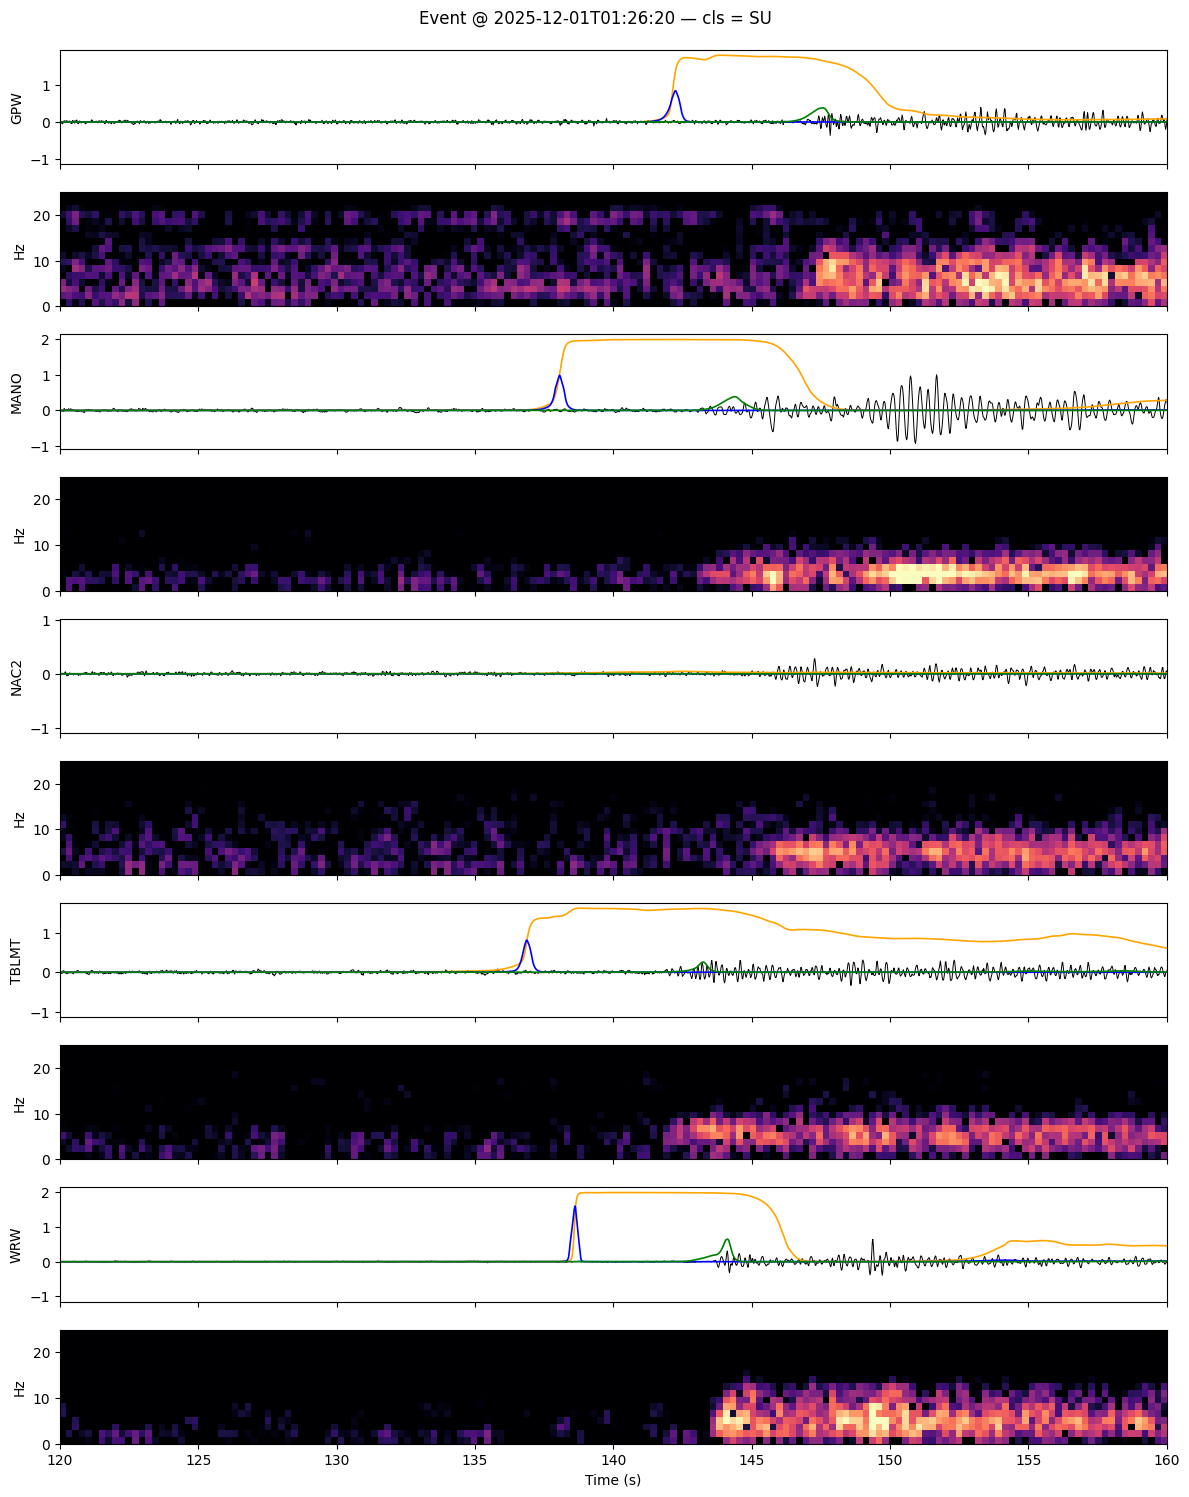

/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/

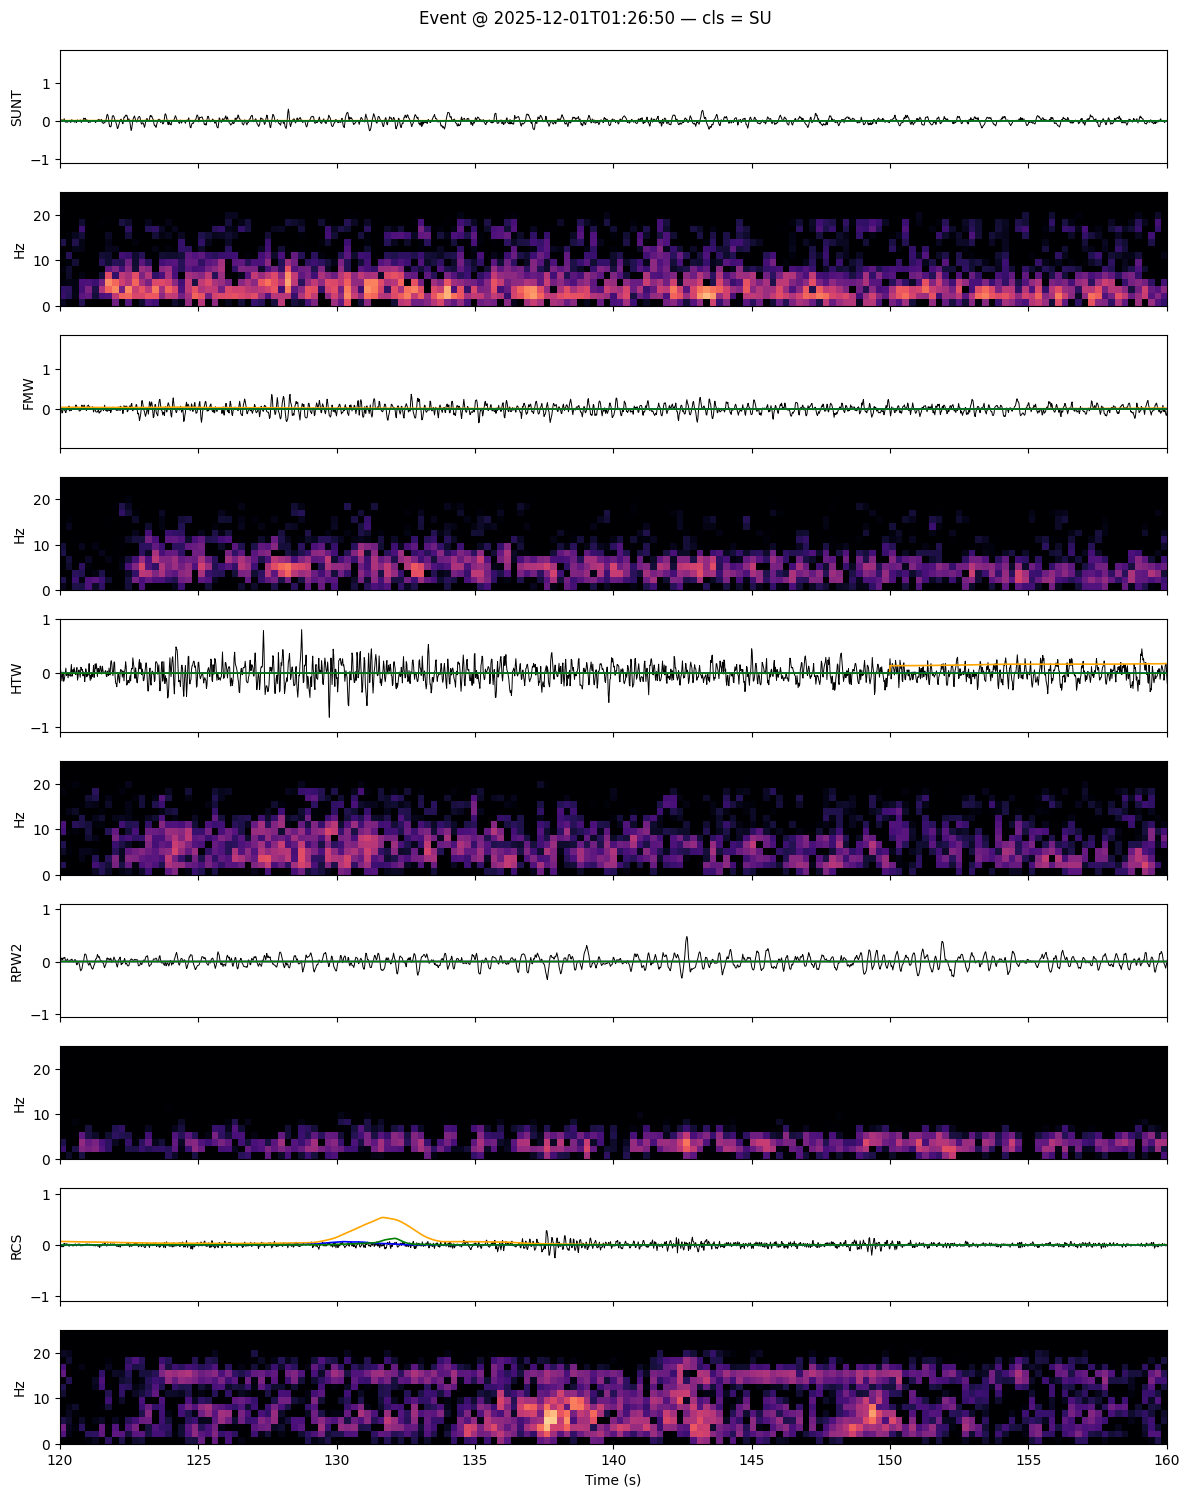

In [54]:
for i in range(2): #(len(uniform_df)):
    plot_event_waveforms_and_picks(uniform_df.iloc[i], duration= 180, model = eqt_model, x1 = 120, x2 = 160)

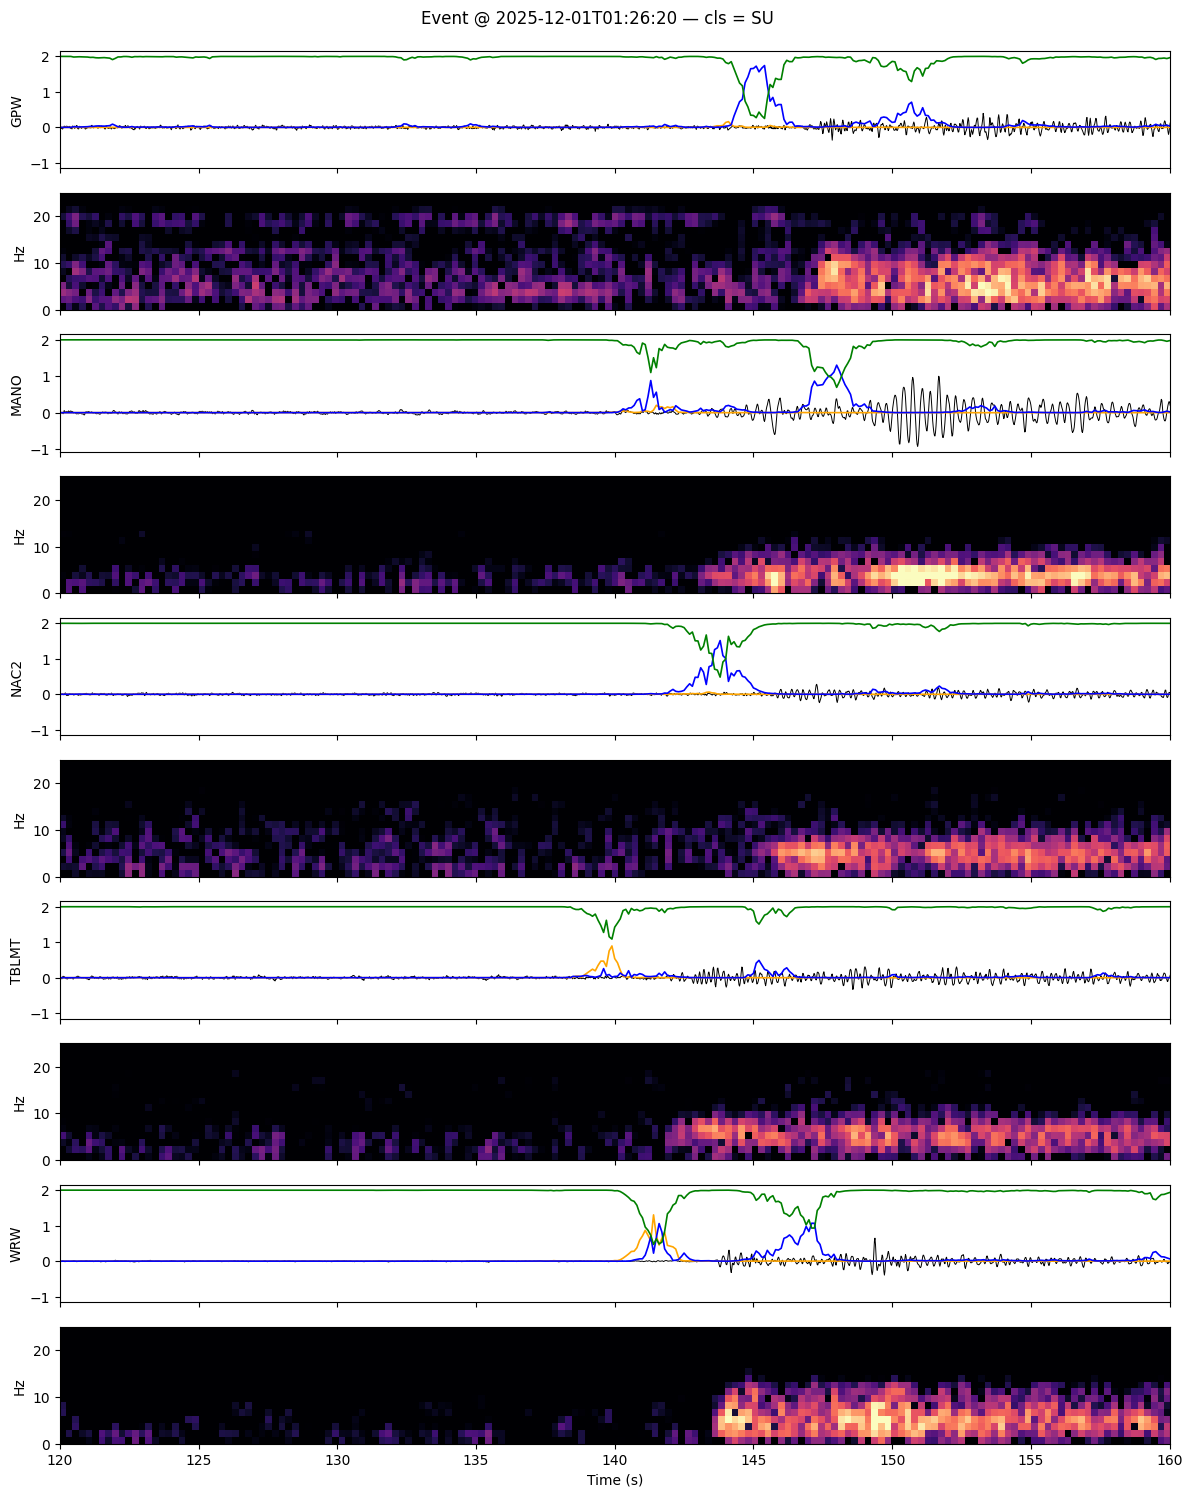

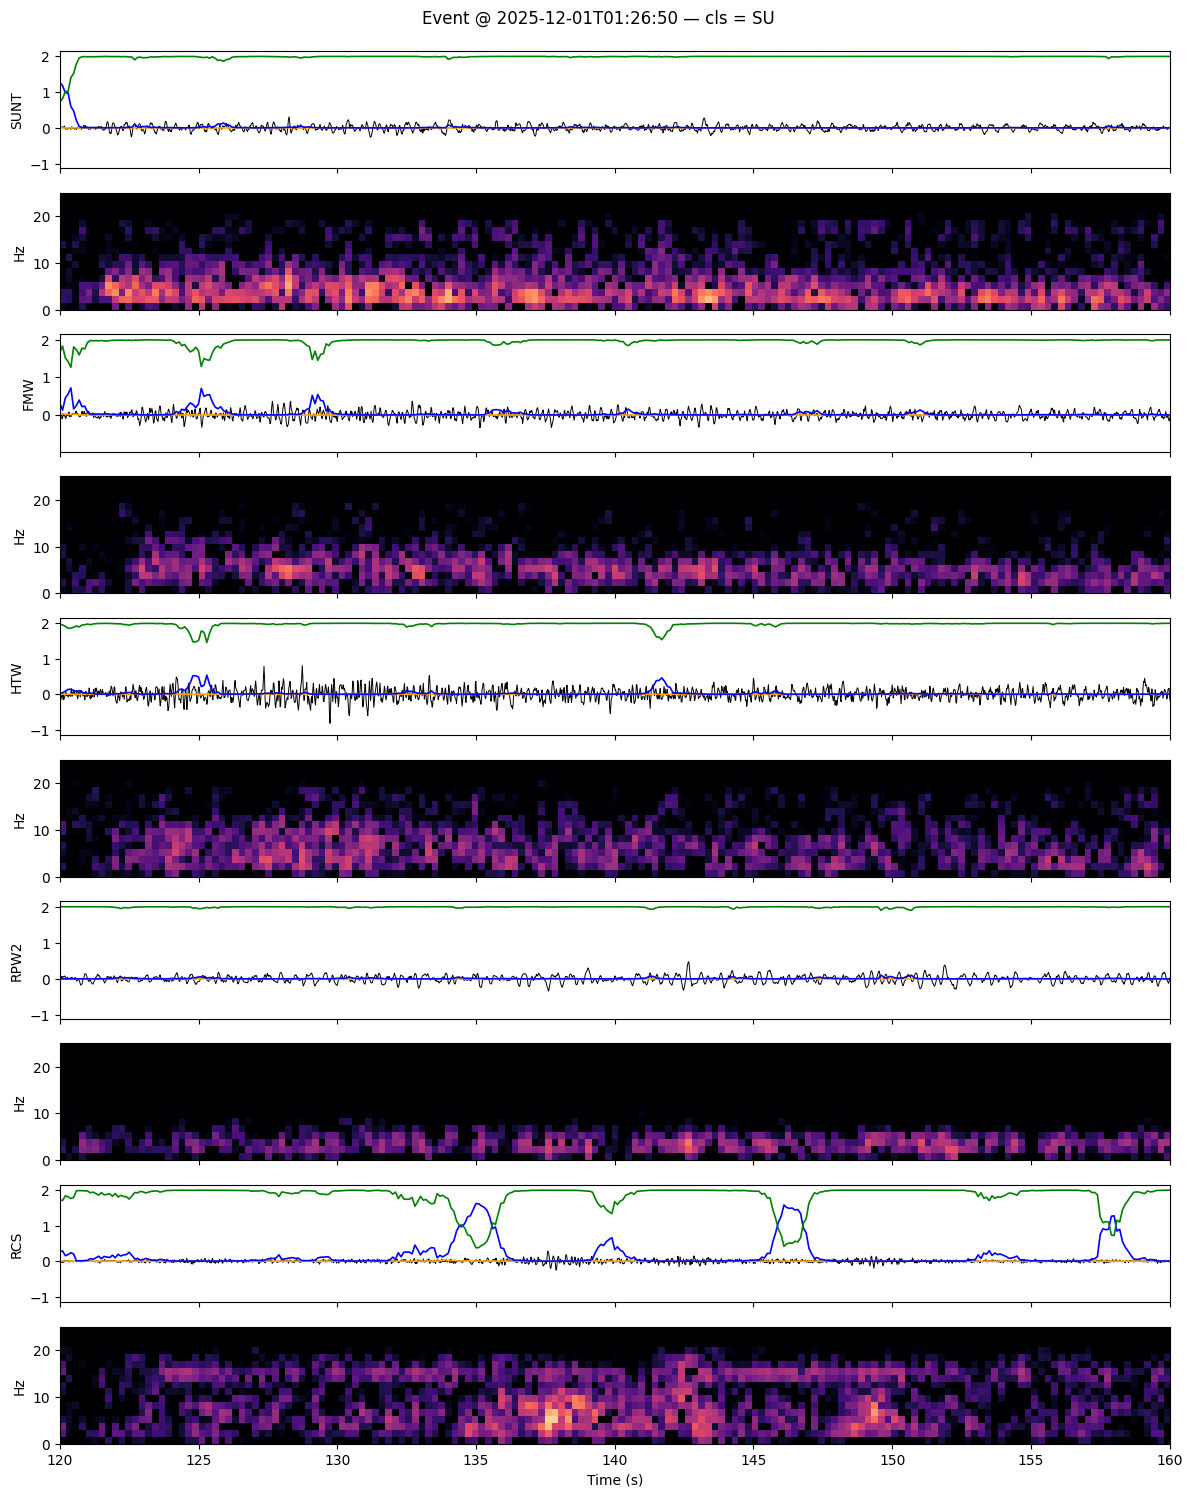

In [55]:
for i in range(2): #(len(uniform_df)):
    plot_event_waveforms_and_picks(uniform_df.iloc[i], duration= 180, model = gpd_model, x1 = 120, x2 = 160)

In [213]:
pn_model.cuda();
eqt_model.cuda();
gpd_model.cuda();

In [ ]:


client = Client("IRIS")
event_time  = UTCDateTime(event_row["rounded_start"])
stream = client.get_waveforms(network="CC", station="PANH", location="*", channel="*H?", 
                              starttime= event_time, 
                              endtime=t+300)


fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(111)
for i in range(3):
    ax.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
ax.legend();